# Demanda Eléctrica en Texas (ERCOT)

## Objetivo y tarea de pronóstico

Antes de explorar, declaramos **qué vamos a predecir**, porque eso define qué estructura
de los datos importa, qué modelo gana y cómo se evalúa:

- **Variable objetivo:** demanda eléctrica horaria de Texas (`cleaned demand (MW)`).
- **Tarea:** pronóstico **multi-paso a 24 horas** (las próximas 24 horas a partir de la
  última observación disponible). Es el horizonte operativamente relevante para ERCOT
  (programación de generación del día siguiente) y el que mejor expone los ciclos
  diario y semanal que veremos en el EDA.
- **Modelos a comparar:** **ARIMA/SARIMA** (modelo estadístico clásico, exige
  estacionariedad) frente a **LSTM** (red recurrente, captura no linealidades y
  dependencias largas sin supuesto de estacionariedad).
- **Métrica:** MAE y RMSE sobre el horizonte de 24 h, más MAPE para lectura relativa.

### Fuente de los datos
Los datos de demanda eléctrica horaria utilizados en este proyecto provienen originalmente de la _U.S. Energy Information Administration (EIA)_, recolectados de las autoridades de balance eléctrico de EUA a través del formulario EIA-930, y disponibles públicamente mediante el portal EIA Open Data (https://www.eia.gov/opendata/).

Debido a inconsistencias y valores faltantes en los datos crudos de la EIA, se utilizó la versión limpia e imputada (mediante la técnica MICE) publicada en el repositorio _EIA_Cleaned_Hourly_Electricity_Demand_Data_, desarrollado por Ruggles, Farnham y colaboradores. Específicamente, se usó el archivo correspondiente a la región de Texas (ERCOT), release de enero de 2025, que cubre el periodo del 1 de enero de 2020 al 1 de enero de 2025. (https://github.com/truggles/EIA_Cleaned_Hourly_Electricity_Demand_Data)

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df = pd.read_csv('Data/TEX.csv', parse_dates=['date_time'], na_values=['MISSING', 'EMPTY'])
df = df.set_index('date_time')

df.shape

print(f"Max date: {df.index.max()}")
print(f"Min date: {df.index.min()}")

print(df['cleaned demand (MW)'].describe())
print(df['cleaned demand (MW)'].isna().sum())

Max date: 2024-12-31 23:00:00
Min date: 2020-01-01 00:00:00
count    43848.000000
mean     48247.804643
std      10947.427884
min      27445.000000
25%      40373.750000
50%      45663.500000
75%      53990.250000
max      85559.000000
Name: cleaned demand (MW), dtype: float64
0


## Zona horaria: los timestamps están en **UTC**, no en hora local de Texas

Esto es un problema al analizar todo esto que es importante tocar si es que se manejan temperaturas (por el momento no se tiene planteado eso).
La demanda horaria de la EIA (fuente de ERCOT)
se publica con marca de tiempo en **UTC**. Si leemos el eje horario de forma literal,
el pico de verano cae cerca de las 22–23 h y el valle cerca de las 10 h, lo cual sería
absurdo en hora local (nadie tiene su máximo de aire acondicionado a las 10 de la noche
ni su mínimo a las 10 de la mañana).

Convertido a **America/Chicago** (hora local de Texas, con horario de verano):
- pico ≈ **17 h (5 PM)** → máximo real de aire acondicionado por la tarde,
- valle ≈ **5 h (5 AM)** → mínimo real de madrugada.

**Para el proyecto:** cuando incorporemos temperatura u
otras covariables climáticas, éstas suelen venir en **hora local**. Mezclar demanda en
UTC con clima en hora local introduce un desfase de **5–6 horas** (oscila porque Texas
cambia a horario de verano) que **destruye la correlación** y nos haría
creer que la temperatura "no sirve". **Decisión:** fijar una sola zona horaria para
todo el pipeline y convertir explícitamente antes de cualquier `merge` temporal.


In [4]:
print(df.index.to_series().diff().value_counts()) 

date_time
0 days 01:00:00    43847
Name: count, dtype: int64


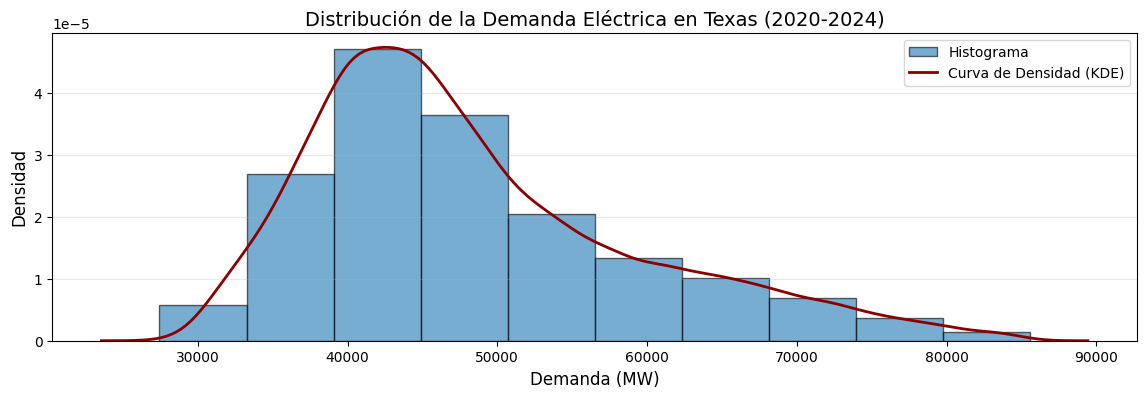

In [5]:
plt.figure(figsize=(14,4))

plt.hist(df['cleaned demand (MW)'], color='#1f77b4', edgecolor='black', density=True, alpha=0.6, label='Histograma')

sns.kdeplot(df['cleaned demand (MW)'], color='darkred', linewidth=2, label='Curva de Densidad (KDE)')

plt.title('Distribución de la Demanda Eléctrica en Texas (2020-2024)', fontsize=14)
plt.xlabel('Demanda (MW)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [6]:
from scipy import stats

d = df['cleaned demand (MW)']

print('Estadisticos de forma y dispersión')
print(d.describe().round(1))
print()
print(f'Asimetría (skew):          {stats.skew(d.dropna()):.3f}')
print(f'Curtosis (exceso):         {stats.kurtosis(d.dropna()):.3f}')
print(f'Coef. de variación:        {d.std()/d.mean():.3f}')

# Razón pico/valle del perfil horario promedio
perfil = d.groupby(d.index.hour).mean()
print(f'Razón pico/valle (perfil horario): {perfil.max()/perfil.min():.3f}')


Estadisticos de forma y dispersión
count    43848.0
mean     48247.8
std      10947.4
min      27445.0
25%      40373.8
50%      45663.5
75%      53990.2
max      85559.0
Name: cleaned demand (MW), dtype: float64

Asimetría (skew):          0.922
Curtosis (exceso):         0.386
Coef. de variación:        0.227
Razón pico/valle (perfil horario): 1.371


## Análisis de la distribución

La densidad (KDE) muestra una distribución **unimodal** con moda alrededor de
**~40,000 MW** y **sesgo a la derecha**. La cola larga la aportan los **picos de verano**
de forma sistemática; el invierno contribuye poco a esa cola de manera estructural y
aparece más como **golpes ocasionales de frío** (uno de ellos, Uri).

Cuantificado:

| Estadístico | Valor |
|---|---|
| Media | 48,248 MW |
| Mediana | 45,664 MW |
| Desv. estándar | 10,947 MW |
| **Asimetría (skew)** | **0.92** (sesgo derecho claro) |
| **Curtosis (exceso)** | **0.39** (colas algo más pesadas que la normal) |
| Mínimo | 27,445 MW |
| Máximo | 85,559 MW |

La asimetría positiva (0.92) confirma que la media (48,248) supera a la mediana (45,664):
hay horas de demanda muy alta poco frecuentes pero significativas.

**Decisiones de modelado derivadas:**
- **ARIMA:** el sesgo a la derecha sugiere evaluar una **transformación log o Box-Cox**
  para estabilizar la varianza antes de ajustar.
- **LSTM:** aplicar **escalado** (MinMax o estandarización) ajustado **solo con el
  conjunto de entrenamiento** para no filtrar información del test.


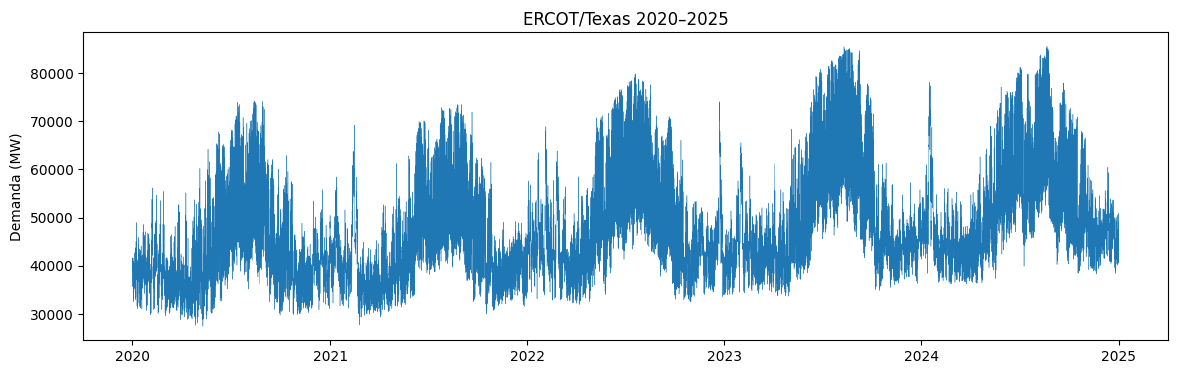

In [7]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['cleaned demand (MW)'], linewidth=0.3)
plt.ylabel('Demanda (MW)'); plt.title('ERCOT/Texas 2020–2025')
plt.show()

## Eventos atípicos y calidad del dato

La serie completa contiene tres situaciones que **no representan demanda normal** y que
hay que **medir** y **convertir en una decisión** antes de modelar:
la tormenta **Uri** (feb-2021), el **confinamiento por COVID** (2020) y las **horas
imputadas** que trae la columna limpia.


In [8]:
# El confinamiento por COVID movió la demanda de forma significativa?
# Comparamos la misma ventana estacional (15-mar a 30-abr) de 2020 vs 2021.
covid_2020 = d['2020-03-15':'2020-04-30'].mean()
base_2021  = d['2021-03-15':'2021-04-30'].mean()
delta = (covid_2020 - base_2021) / base_2021 * 100

print(f'Demanda media 15-mar a 30-abr 2020 (confinamiento): {covid_2020:,.0f} MW')
print(f'Demanda media 15-mar a 30-abr 2021 (referencia):    {base_2021:,.0f} MW')
print(f'Diferencia: {delta:+.2f} %  esto pues dentro del ruido, NO es un efecto significativo')


Demanda media 15-mar a 30-abr 2020 (confinamiento): 37,788 MW
Demanda media 15-mar a 30-abr 2021 (referencia):    38,211 MW
Diferencia: -1.11 %  esto pues dentro del ruido, NO es un efecto significativo


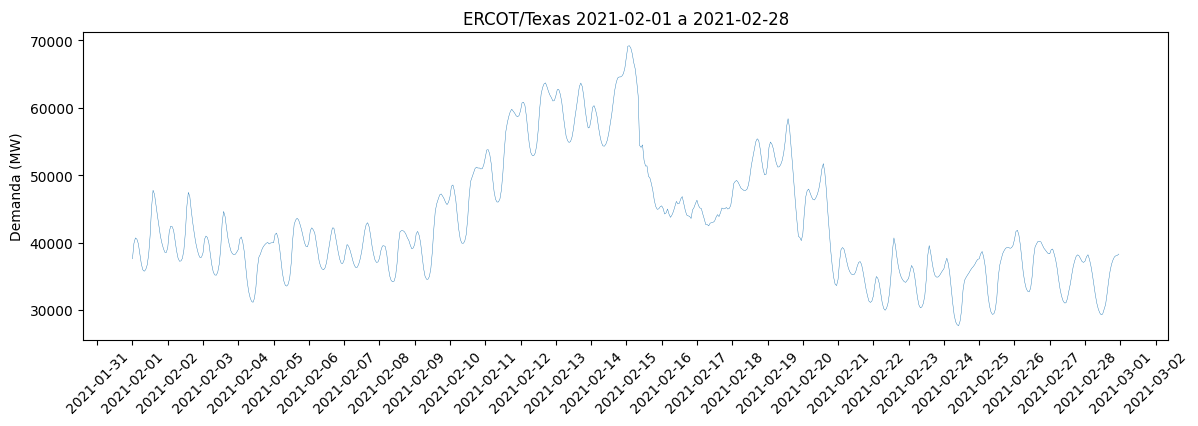

In [9]:

# Acercarse a las dos semanas con hora y todos los dias completos
sub = df.loc['2021-02-01':'2021-02-28', 'cleaned demand (MW)']
plt.figure(figsize=(14,4))
plt.plot(sub.index, sub.values, linewidth=0.3)
plt.ylabel('Demanda (MW)')
plt.title('ERCOT/Texas 2021-02-01 a 2021-02-28')

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()

In [10]:
# Punto 3 — La columna 'raw demand' vs 'cleaned demand': qué se imputó y dónde?
corr = df['raw demand (MW)'] - df['cleaned demand (MW)']
imputado = corr != 0

print(f'Horas con valor imputado/corregido: {imputado.sum()} '
      f'({imputado.mean()*100:.2f}% de la serie)')
print(f'Corrección mediana: {corr[imputado].abs().median():,.0f} MW') # Nota : casi cosmetica
print(f'Corrección máxima:  {corr.abs().max():,.0f} MW')

# Dónde se concentran las imputaciones?
conc = (imputado.groupby([imputado.index.year, imputado.index.month]).sum()
        .sort_values(ascending=False).head(5))
print('\nMeses con más horas imputadas:')
print(conc)

# La corrección más grande NO está en Uri
peor = corr.abs().idxmax()
print(f'\nMayor corrección en: {peor}')
print(df.loc[peor])


Horas con valor imputado/corregido: 549 (1.25% de la serie)
Corrección mediana: 254 MW
Corrección máxima:  45,525 MW

Meses con más horas imputadas:
date_time  date_time
2023       10           73
           3            65
2022       2            29
2021       2            28
2024       11           25
dtype: int64

Mayor corrección en: 2024-08-25 22:00:00
raw demand (MW)        34066
cleaned demand (MW)    79591
Name: 2024-08-25 22:00:00, dtype: int64


### Hallazgos y decisiones sobre eventos atípicos y dato no confiable

**Tormenta Uri (feb-2021) — descripción/decisión.** El 9–10 de febrero de 2021 una
tormenta invernal extrema dispara la demanda de calefacción; del 14 al 19 de febrero la
serie **cae bruscamente**. Ese desplome **no es demanda real**: durante el apagón el dato
registrado es carga servida, limitada por la falta de generación es demanda no
satisfecha, un dato corrupto para pronóstico. y pues se toma una
decisión: **esta ventana no representa demanda real** se optó por mantenerla en el conjunto de entrenamiento y FUERA del test, para no evaluar ningún modelo sobre datos corruptos.

**COVID-19 (2020) — medido, no afirmado.** El confinamiento (15-mar a 30-abr 2020) dio
una demanda media de **37,788 MW** frente a **38,211 MW** en la misma ventana de 2021:
**−1.1 %**, dentro del ruido. En Texas (mezcla industrial/residencial distinta a otras
regiones) el confinamiento **apenas movió** la demanda. **Decisión:** no tratarlo como
choque estructural; basta con asegurar que 2020 caiga en **entrenamiento**.

**Horas imputadas — la columna que no debíamos ignorar.** El **1.25 % (549 horas)** de la
variable objetivo es **sintético**: lo imputó el algoritmo de limpieza de la fuente. No se
concentran en Uri sino en **octubre 2023 (73 h)** y **marzo 2023 (65 h)**. La corrección
mediana es **254 MW** (casi nadita), pero existe una de **45,525 MW** un valor crudo
roto (raw ≈ 34,066 → limpio ≈ 79,591). esa corrección máxima **no es de Uri**, ocurre
el **2024-08-25** (pico de verano). **Decisión:** conservar una bandera `es_imputado` y, si
el conjunto de prueba cae sobre horas imputadas, reportarlo — evaluar un modelo contra
horas inventadas es calificarlo contra ficción.


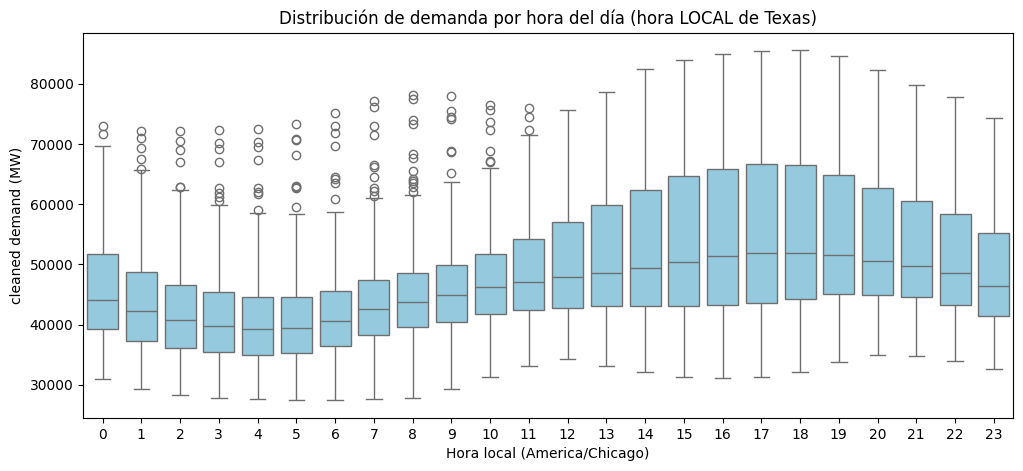

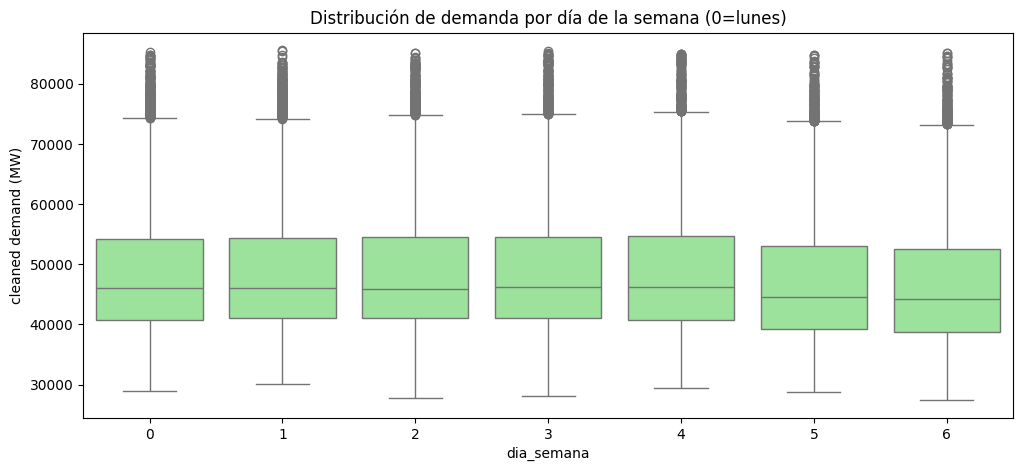

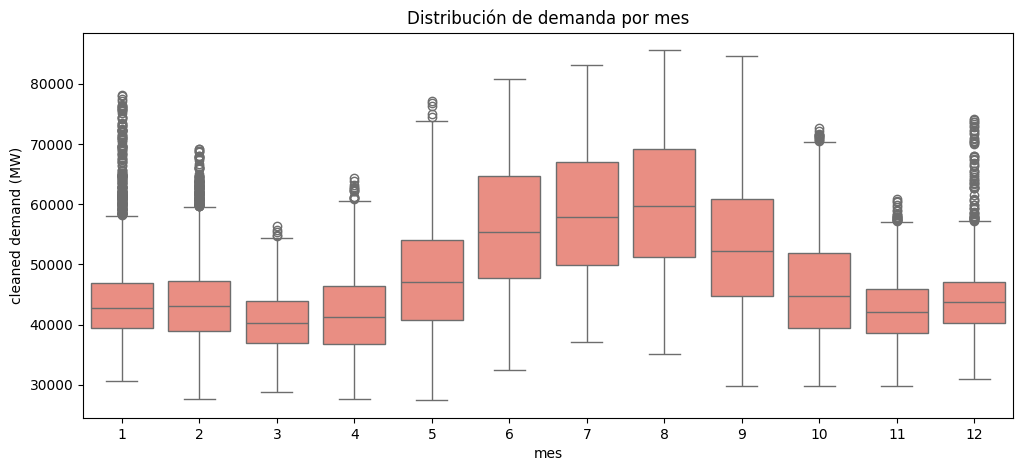

In [11]:
# Convertimos a hora local de Texas para que las etiquetas tengan sentido físico.
idx_local = df.index.tz_localize('UTC', ambiguous='NaT', nonexistent='NaT').tz_convert('America/Chicago')

df['hora_utc']   = df.index.hour            # como vienen los datos (UTC)
df['hora_local'] = idx_local.hour           # hora real de Texas
df['dia_semana'] = idx_local.dayofweek
df['mes']        = idx_local.month

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='hora_local', y='cleaned demand (MW)', color='skyblue')
plt.title('Distribución de demanda por hora del día (hora LOCAL de Texas)')
plt.xlabel('Hora local (America/Chicago)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='dia_semana', y='cleaned demand (MW)', color='lightgreen')
plt.title('Distribución de demanda por día de la semana (0=lunes)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='mes', y='cleaned demand (MW)', color='salmon')
plt.title('Distribución de demanda por mes')
plt.show()


## Ciclos observados (con números y en hora local)

- **Ciclo diario (en hora local de Texas):** pico alrededor de las **17 h (5 PM)** y valle
  hacia las **5 h (5 AM)**; en julio el pico es exactamente a las 17 h. La razón
  **pico/valle del perfil horario promedio es 1.37** (la demanda de la tarde es ~37 %
  mayor que la de la madrugada). *Nota: leído en UTC el pico aparece a las ~22 h por el
  desfase descrito arriba.*

- **Ciclo semanal:** los días **laborales** son ligeramente superiores a los **fines de
  semana** (~48,700 MW vs ~47,100 MW de media). El efecto existe pero es **modesto**
  comparado con los ciclos diario y anual.

- **Ciclo anual:** picos en **verano** (jun–ago), con **agosto** como mes de mayor
  demanda (mediana **~59,800 MW**) y **marzo** como el menor (mediana **~40,200 MW**).
  La brecha mediana verano–invierno es de **~19,600 MW**, una variación enorme.

**Decisiones de modelado derivadas:**
- Hay **estacionalidad múltiple** (diaria, semanal, anual). Para el modelo estadístico
  usar **SARIMA** con período estacional, o incorporar variables de calendario
  (hora, día de semana, mes) y términos de **Fourier** para las estacionalidades largas.
- Para la **LSTM**, la ventana de entrada debe cubrir al menos un ciclo diario completo
  (≥ 24 pasos) y conviene añadir features cíclicas (seno/coseno de hora y día).


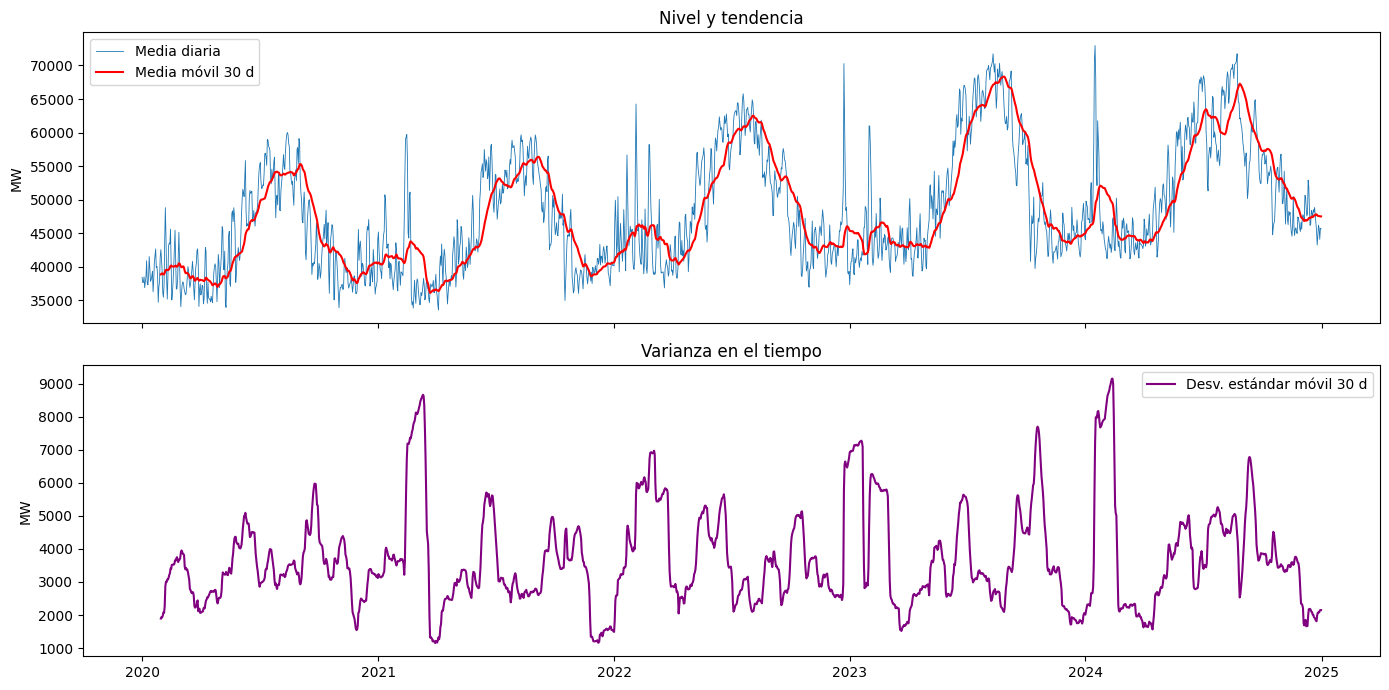

ADF sobre la serie horaria -> estadístico: -7.167 | p-valor: 0.0000
p < 0.05 => se rechaza H0 (estacionaria en sentido débil); aun así domina la fuerte estacionalidad anual.


In [12]:
# Punto 5 — Estacionariedad (supuesto central de ARIMA)
from statsmodels.tsa.stattools import adfuller

serie_dia = d.resample('D').mean()   # media diaria para ver tendencia/varianza con claridad

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].plot(serie_dia.index, serie_dia.values, linewidth=0.6, label='Media diaria')
ax[0].plot(serie_dia.rolling(30).mean(), color='red', label='Media móvil 30 d')
ax[0].set_ylabel('MW'); ax[0].legend(); ax[0].set_title('Nivel y tendencia')
ax[1].plot(serie_dia.rolling(30).std(), color='purple', label='Desv. estándar móvil 30 d')
ax[1].set_ylabel('MW'); ax[1].legend(); ax[1].set_title('Varianza en el tiempo')
plt.tight_layout(); plt.show()

# Prueba ADF (H0: la serie tiene raíz unitaria = NO estacionaria)
adf = adfuller(d.dropna(), autolag='AIC')
print(f'ADF sobre la serie horaria -> estadístico: {adf[0]:.3f} | p-valor: {adf[1]:.4f}')
print('p < 0.05 => se rechaza H0 (estacionaria en sentido débil); '
      'aun así domina la fuerte estacionalidad anual.')


### decisiones

La media móvil muestra una **fuerte oscilación estacional anual** (verano alto, invierno
bajo) y la desviación estándar móvil **no es constante**: la varianza es mayor en los meses
de verano (**heterocedasticidad estacional**). La serie horaria pasa la prueba ADF
(p < 0.05) por la masa de observaciones, pero eso **no elimina la estacionalidad**.

**Decisiones de modelado derivadas:**
- **ARIMA:** la serie **no es estacionaria en media estacional** → aplicar **diferenciación
  estacional** (p. ej. SARIMA con período diario/anual) y considerar transformación
  **log/Box-Cox** para la varianza creciente en verano. Verificar residuos con ACF/PACF.
- **LSTM:** no exige estacionariedad, pero el escalado y las features de calendario ayudan
  a que aprenda los ciclos sin tener que reconstruir la tendencia estacional desde cero.


## Resumen

| Hallazgo del EDA | Decisión de modelado |
|---|---|
| Timestamps en **UTC** (pico real 17 h local) | Fijar una zona horaria única; convertir antes de unir clima/temperatura para evitar desfase de 5–6 h |
| Distribución **sesgo derecho** (skew 0.92, curtosis 0.39) | log/Box-Cox para ARIMA; escalado (solo con train) para LSTM |
| **Estacionalidad múltiple** (diaria 1.37×, semanal leve, anual ~19,600 MW) | SARIMA / términos de Fourier; features de calendario y cíclicas; ventana LSTM ≥ 24 h |
| Serie **no estacionaria** en media/varianza estacional | Diferenciación estacional + transformación de varianza para ARIMA |
| **COVID** = −1.1 % (ruido) | No es choque estructural, 2020 va en train |
| **1.25 % (549 h) imputado**, máx 45,525 MW (ago-2024) | Bandera `es_imputado`, reportar si el test cae sobre horas imputadas |
| **Tarea: pronóstico a 24 h** | Define horizonte de evaluación (MAE/RMSE/MAPE a 24 h) y diseño walk-forward |


___

### Método de evaluacion reutilizable 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(real, pred, name='Model', graficar=True):
    """
    Recibe predicciones + reales (series de pandas) y calcula MAE, RMSE y MAPE. y opcionalmente grafica predicciones vs reales.
    """

    real, pred = real.align(pred, join='inner')  # Alinea las series para que tengan el mismo índice
   
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = (np.abs((real - pred) / real)).mean() * 100

    print(f'{name} - MAE: {mae:,.0f} MW')
    print(f'{name} - RMSE: {rmse:,.0f} MW')
    print(f'{name} - MAPE: {mape:.2f} %')

    if graficar:
        plt.figure(figsize=(14,4))
        plt.plot(real.index, real.values, color='blue', linewidth=0.5, label='Real')
        plt.plot(pred.index, pred.values, color='orange', linewidth=0.5, label=name)
        plt.title(f'Predicción {name} vs Real (2024)')
        plt.xlabel('Fecha')
        plt.ylabel('Demanda (MW)')
        plt.legend()
        plt.show()

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

Naive Method - MAE: 1,509 MW
Naive Method - RMSE: 1,870 MW
Naive Method - MAPE: 2.81 %


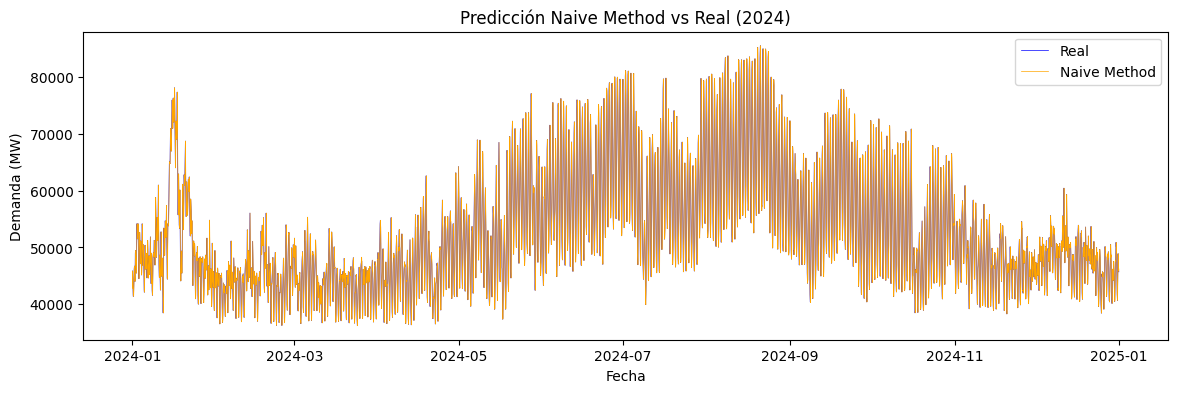

Seasonal Naive 24h - MAE: 2,359 MW
Seasonal Naive 24h - RMSE: 3,405 MW
Seasonal Naive 24h - MAPE: 4.51 %


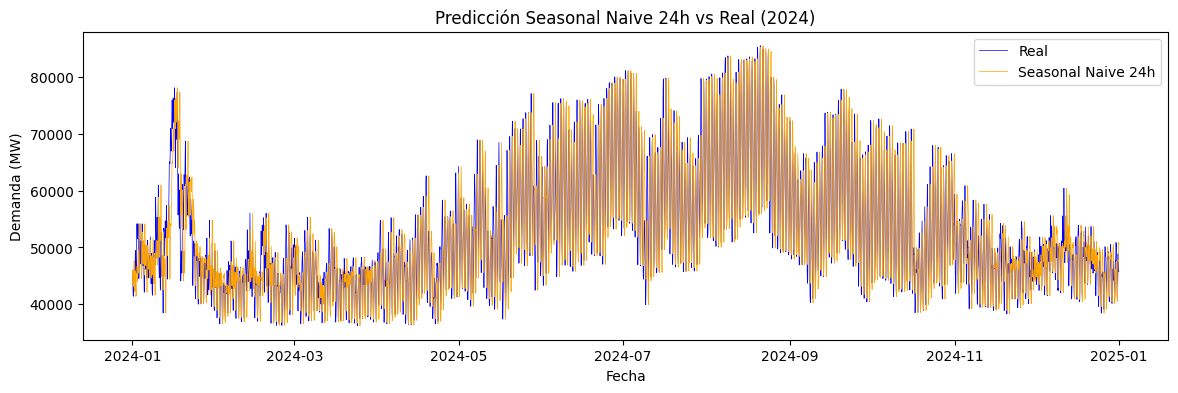

Seasonal Naive 168h - MAE: 4,476 MW
Seasonal Naive 168h - RMSE: 6,265 MW
Seasonal Naive 168h - MAPE: 8.33 %


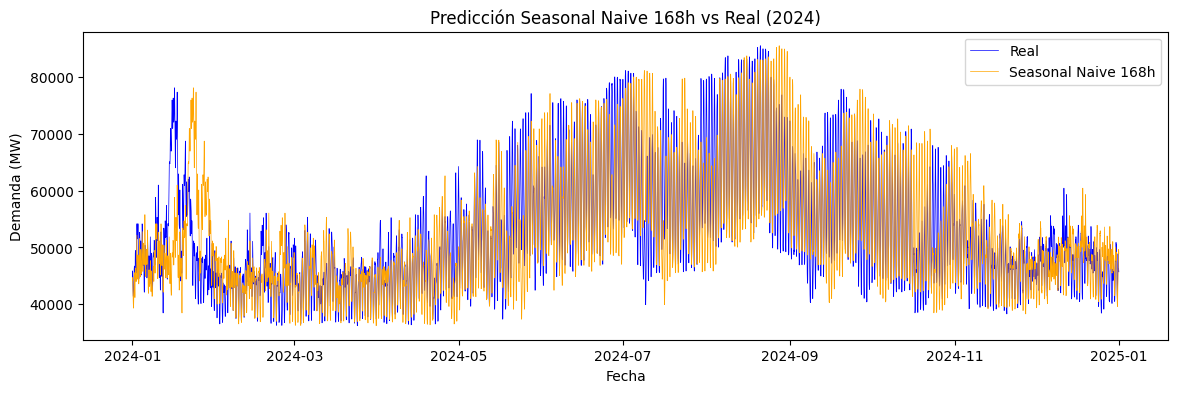

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive Method (la predicción para el tiempo t es el valor observado en t-1)
df['prediction_naive'] = df['cleaned demand (MW)'].shift(1)

# Seasonal Naive (la predicción para el tiempo t es el valor observado en t-24h)
df['prediction_snaive_24h'] = df['cleaned demand (MW)'].shift(24)

df['prediction_snaive_168h'] = df['cleaned demand (MW)'].shift(168)  # 7 días atrás

eval_df = df.dropna(subset=['cleaned demand (MW)', 'prediction_naive', 'prediction_snaive_24h', 'prediction_snaive_168h'])


test = eval_df.loc['2024-01-01':'2024-12-31']

r_naive = evaluate(test['cleaned demand (MW)'], test['prediction_naive'], name='Naive Method')
r_snaive_24h = evaluate(test['cleaned demand (MW)'], test['prediction_snaive_24h'], name='Seasonal Naive 24h')
r_snaive_168h = evaluate(test['cleaned demand (MW)'], test['prediction_snaive_168h'], name='Seasonal Naive 168h')

## Interpretación de los baselines

**La brecha RMSE > MAE**

En los tres modelos el RMSE supera al MAE (S-Naive 24h: **3,405 vs 2,359 MW**). Eso es esperado y nunca es negativo; lo informativo es **qué tan grande** es la separación. Una brecha amplia indica una distribución del error con **colas pesadas**: la mayoría de las horas se predicen razonablemente bien, pero hay horas con errores muy grandes, los cambios bruscos de demanda que vimos en el EDA (picos de verano, rampas de la tarde) que el RMSE amplifica. Cuanto mayor la separación, más concentrado está el error en pocos momentos difíciles.

**El propósito: piso a vencer**

| Modelo | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Naive (t-1) | 1,509 | 1,870 | 2.81 |
| **Seasonal Naive 24h** | **2,359** | **3,405** | **4.51** |
| Seasonal Naive 168h | 4,476 | 6,265 | 8.33 |

El **Naive (t-1)** parece el mejor, pero es **engañoso**: copiar el valor de la hora anterior solo funciona a 1 paso y **no es un pronóstico real** para nuestra tarea. Al predecir las próximas 24 horas no disponemos del valor de t-1 (es justo lo que queremos estimar), así que ese 2.81 % es un número irreal para el horizonte que nos importa.

El **Seasonal Naive 168h** (una semana atrás) se degrada porque la demanda cambia más entre semanas (clima, estacionalidad anual) que entre días equivalentes.

El **Seasonal Naive 24h** aprovecha el fuerte ciclo diario de la demanda (cada hora se parece a la misma hora del día anterior, razón pico/valle 1.37 del EDA), está disponible en el horizonte de 24 h. **Su MAPE de ~4.5 % es el piso a vencer.** SARIMA y la LSTM deben quedar por debajo de ese error; si no lo logran, no están capturando nada que un simple "ayer a esta hora" no explique ya.

In [15]:
# Crear split (train 2020-2022, val 2023, test 2024)

fin_train = '2022-12-31 23:59:59'
fin_val   = '2023-12-31 23:59:59'


train = df.loc[:fin_train, 'cleaned demand (MW)']
val = df.loc[fin_train:fin_val, 'cleaned demand (MW)']
test = df.loc[fin_val:, 'cleaned demand (MW)']

print("Split de la serie:")
print(f"Train: {train.index.min()} a {train.index.max()} | Horas: {len(train)}")
print(f"Val:   {val.index.min()} a {val.index.max()}     | Horas: {len(val)}")
print(f"Test:  {test.index.min()} a {test.index.max()}     | Horas: {len(test)}")

Split de la serie:
Train: 2020-01-01 00:00:00 a 2022-12-31 23:00:00 | Horas: 26304
Val:   2023-01-01 00:00:00 a 2023-12-31 23:00:00     | Horas: 8760
Test:  2024-01-01 00:00:00 a 2024-12-31 23:00:00     | Horas: 8784


___

### Modelo Holt-Winters

Holt-Winters WF - MAE: 4,676 MW
Holt-Winters WF - RMSE: 6,670 MW
Holt-Winters WF - MAPE: 9.21 %


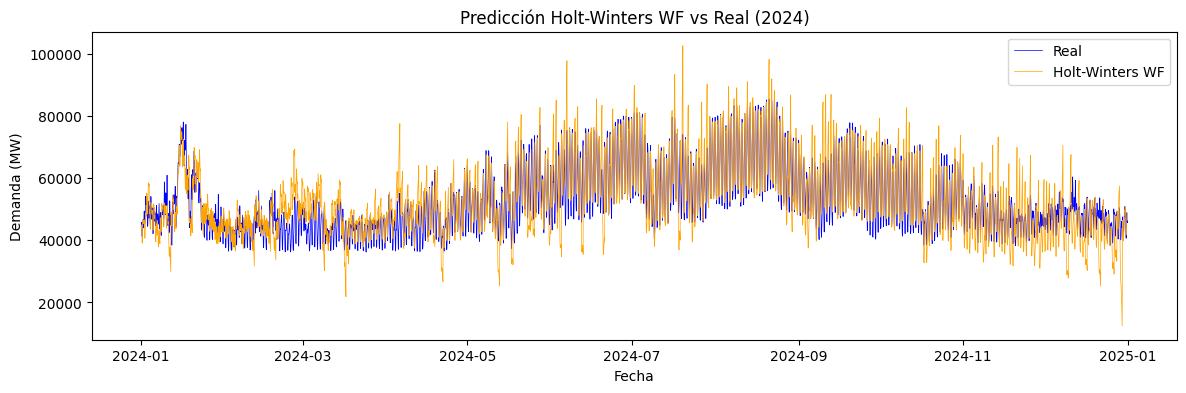

In [ ]:
# Ajustar un modelo holt-winters sobre el train 
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

serie = df['cleaned demand (MW)']

H = 24  # periodicidad diaria
ventana = 60*24 # 60 dias 

inicio_test = serie.index.get_loc('2024-01-01 00:00:00') 
fin_test = len(serie)

predicciones = []
indices = []

for origen in range(inicio_test, fin_test - H + 1, H):

    # 1) Datos para entrenar: SOLO lo anterior al 'origen' (esto evita la fuga)
    historia = serie.iloc[origen - ventana:origen]    # una ventana de tamaño VENTANA que TERMINA en 'origen'

    # 2) Ajustar Holt-Winters con esa historia
    modelo = ExponentialSmoothing(historia, trend='add', seasonal='mul', seasonal_periods=24).fit()

    # 3) Pronosticar las próximas H horas
    pred = modelo.forecast( H )   # ¿cuántos pasos? (NO len(test))

    # 4) Guardar las predicciones y las fechas a las que corresponden
    predicciones.extend(pred)
    indices.extend(serie.index[origen : origen + H])

# Juntar todo y calcular métricas (igual que antes)
pred_hw = pd.Series(predicciones, index=indices)
real    = serie.loc[pred_hw.index]

r_hw = evaluate(real, pred_hw, name='Holt-Winters WF')

# Comparación entre Holt-Winters y Seasonal Naive 

Se entreno un modelo de Holt-Winters con los mismos datos con un walk-forward de 24h  y se comparo con el Seasonal Naive 24h.

El modelo de Holt-Winters obtuvo un MAE de 4,676 MW y RMSE de 6,670 MW, mientras que el Seasonal Naive 24h obtuvo un MAE de 2,359 MW y RMSE de 3,405 MW. 

| Modelo | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Holt-Winters | 4,676 | 6,670 | 9.21 |
| **Seasonal Naive 24h** | **2,359** | **3,405** | **4.51** |

Aquí nos damos cuenta que el modelo de Holt-Winters no logra superar el piso tiene el doble de error y pierde en 11 de 12 meses (9.21% vs 4.51%), lo que indica que no está capturando mejor los patrones de la demanda que un simple modelo estacional.

### Entonces, ¿por qué un promedio pierde contra copiar el dato real reciente? 
El Seasonal Naive predice la hora de hoy copiando el valor real de ayer a esa misma hora. Pero ese valor no es solo un número: carga la información de las condiciones de ayer qué tan caluroso estuvo, si fue día laboral, el nivel general de demanda. Y como la demanda es muy persistente día a día (si ayer hizo calor y fue alta, hoy probablemente también), copiar ayer le da gratis el estado reciente.
Holt-Winters, en cambio, tira esa información a la basura: construye una forma diaria promedio sobre 60 días y la aplica. Promediar borra a propósito lo específico de cada día. Entonces, cualquier día que se desvíe del promedio de 60 días (que son casi todos, en algún grado) HW predice el promedio y le erra, mientras el naive sigue el estado real reciente. Eso es estructural y pasa siempre, por eso pierde hasta en los meses tranquilos. También el período de 24 solo conoce el ciclo diario, no el semanal. Holt-Winters no tiene forma de representar "entre semana vs fin de semana", cada sábado y domingo predice una forma de día laboral y le erra. Eso pasa 52 veces al año, siempre.

### ¿Descartamos el suavizado exponencial? ¿Qué se espera de ARIMA? 

El suavizado exponencial, como el modelo de Holt-Winters, es un método que asigna más peso a las observaciones recientes para capturar tendencias y estacionalidades. Sin embargo, en este caso específico de la demanda eléctrica en Texas, el modelo de Holt-Winters no logró superar el rendimiento del Seasonal Naive 24h, lo que sugiere que el suavizado exponencial puede no ser lo suficientemente flexible para capturar los patrones complejos de la demanda eléctrica.

ARIMA, por otro lado, es un modelo estadístico que puede capturar tanto la tendencia como la estacionalidad de una serie temporal, y también puede manejar la heterocedasticidad mediante transformaciones. ARIMA puede hacer lo mismo que el naive (apoyarse en el dato reciente) y además meterle estructura estacional. Esa es la razón por la que ARIMA podría pelearle al naive: no porque "siga mejor los eventos raros", sino porque no tira a la basura el estado reciente como hace Holt-Winters.

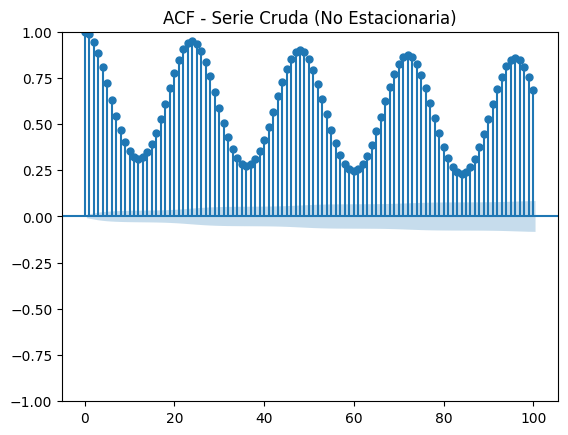

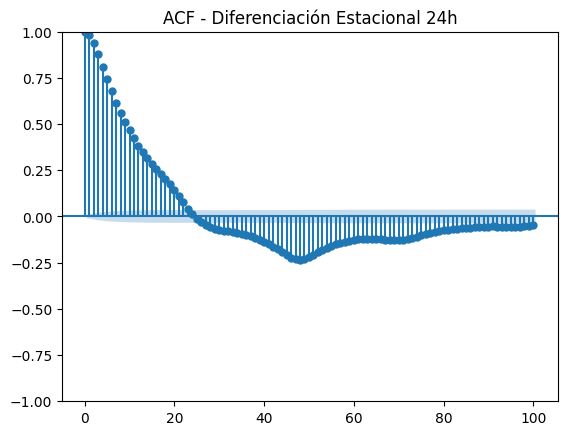

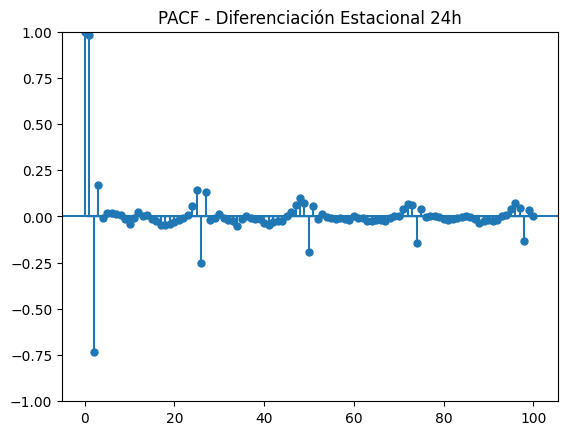

In [ ]:
# Graficar el ACF
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['cleaned demand (MW)'], lags=100)
plt.title("ACF - Serie Cruda (No Estacionaria)")
plt.show()

# Aplicar diferenciación estacional (24h) para ver si se estaciona la serie

demanda_diff = df['cleaned demand (MW)'].diff(24).dropna()

plot_acf(demanda_diff, lags=100)
plt.title("ACF - Diferenciación Estacional 24h")
plt.show()

# Ahora graficar el PACF para ver si hay correlación parcial significativa

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(demanda_diff, lags=100)
plt.title("PACF - Diferenciación Estacional 24h")
plt.show()

Tras graficar el ACF y el PACF respectivos aplicando una diferenciacion estacional de 24h, también guiandonos por la regla de Box-Jenkins Toda la lectura de ACF/PACF se reduce a reconocer cuál de esas dos formas tiene cada una. La regla usada es esta:

![ACF diferenciada a 24](image/Screenshot_2026-06-24_at_2.52.57_p.m.-removebg-preview.png)

| Forma de la ACF | Forma de la PACF | Conclusión |
|---|---|---|
| cola (decae gradual) | corte (cae de golpe tras lag p) | AR(p) — usa términos AR |
| corte (cae de golpe tras lag q) | cola (decae gradual) | MA(q) — usa términos MA |
| cola | cola | ARMA (mezcla de ambos) |
| muy lenta, casi no decae | - | no estacionaria → diferencia primero |

La ACF cruda oscila con picos en 24, 48, 72… que decaen lento. Eso es justo la última fila de la tabla: no estacionaria + estacionalidad diaria fuerte. Por eso diferenciaste a 24.

Una vez diferenciada a 24, la ACF decae gradualmente (cola) y la PACF se corta temprano. Esta combinación indica un **AR** de orden 2 con picos estacionales que sugieren además un componente AR estacional.

Los candidatos a comparar es entonces un **SARIMA(2,0,0)(1,1,0,24)**. El primer paréntesis es el ARMA no estacional (p=2, d=0, q=0) y el segundo paréntesis es el estacional (P=1, D=1, Q=0, s=24).


___

# Modelo SARIMA(2,0,0)(1,1,0,24)

In [56]:
import statsmodels.api as sm

# Funcion para walk-forward SARIMA
def walk_forward_sarima(serie, H, order=(2, 0, 0), seasonal_order=(1, 1, 0, 24),ventana=60*24, inicio='2024-01-01 00:00:00'):
    inicio_test = serie.index.get_loc(inicio)
    fin_test = len(serie)

    predicciones, indices = [], []
    fallos = 0

    for origen in range(inicio_test, fin_test - H + 1, H):
        # 1) Datos para entrenar: SOLO lo anterior al 'origen'
        historia = serie.iloc[origen - ventana:origen]          # solo el pasado (evita fuga)

        try:
            # 2) Ajustar SARIMA con esa historia
            model = sm.tsa.SARIMAX(historia, order=order, seasonal_order=seasonal_order).fit(disp=False)

            # 3) Pronosticar las próximas H horas
            pred = model.get_forecast(steps=H).predicted_mean

            # 4) Guardar las predicciones y las fechas a las que corresponden
            predicciones.extend(pred)
            indices.extend(serie.index[origen:origen + H])

        except Exception:
            fallos += 1

    print(f"Bloques usados: correcto | omitidos por no converger: {fallos}")
    return pd.Series(predicciones, index=indices)

SARIMA(2,0,0)(1,1,0)24 - MAE: 2,164 MW
SARIMA(2,0,0)(1,1,0)24 - RMSE: 3,144 MW
SARIMA(2,0,0)(1,1,0)24 - MAPE: 4.18 %


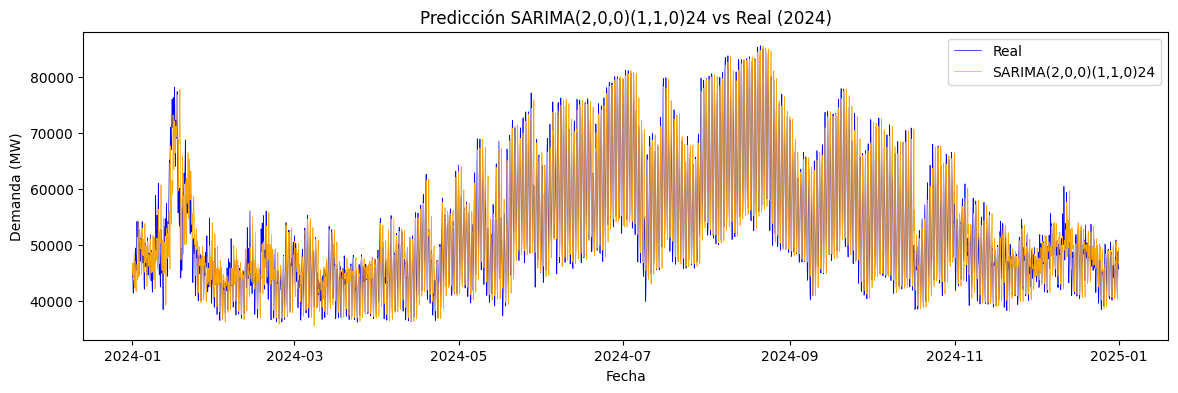

In [50]:
pred_sm_24 = walk_forward_sarima(serie, H=24)   # reproduce el experimento de 24h
real = serie.loc[pred_sm_24.index]
r_sm = evaluate(real, pred_sm_24, name='SARIMA(2,0,0)(1,1,0)24')

In [20]:
summary = pd.DataFrame([r_naive, r_snaive_24h, r_snaive_168h, r_hw, r_sm]).set_index('Model')
summary.round(2)

,MAE,RMSE,MAPE
Model,,,
Naive Method,1509.44,1869.61,2.81
Seasonal Naive 24h,2359.44,3404.57,4.51
Seasonal Naive 168h,4475.99,6265.41,8.33
Holt-Winters WF,4675.66,6669.57,9.21
"SARIMA(2,0,0)(1,1,0)24",2164.02,3144.17,4.18


Se ajusta un **SARIMA(2,0,0)(1,1,0)[24]** a la demanda eléctrica horaria de Texas con validación walk-forward a un horizonte de **24 h** (se reajusta el modelo cada día sobre una ventana de 60 días y se pronostican las 24 h siguientes), para compararlo contra Holt-Winters y contra el piso del **Seasonal Naive 24h**.

| Model | MAE | RMSE | MAPE |
|---|---:|---:|---:|
| Seasonal Naive 24h | 2359.44 | 3404.57 | 4.51 |
| Holt-Winters WF | 4675.66 | 6669.57 | 9.21 |
| **SARIMA(2,0,0)(1,1,0)24** | **2164.02** | **3144.17** | **4.18** |

SARIMA da **MAE 2,164 MW · RMSE 3,144 MW · MAPE 4.18 %**. Es el único modelo entrenable (es decir, un pronóstico real a 24 h, no el Naive(t-1) que hace trampa con el dato de hace una hora) que baja del piso.

### ¿Cómo se compara contra el piso?

Mejor, en las tres métricas, pero por un margen modesto:

| Métrica | Seasonal Naive | SARIMA | Mejora relativa |
|---|---:|---:|---:|
| MAPE | 4.51 % | 4.18 % | **−7.3 %** |
| RMSE | 3,404.57 | 3,144.17 | **−7.7 %** |
| MAE | 2,359.44 | 2,164.02 | **−8.3 %** |

Y a diferencia de Holt-Winters que perdía con el doble de error SARIMA, sí cumple lo que predijimos en la sección de Holt-Winters: que un modelo capaz de apoyarse en el estado reciente sin tirarlo a la basura podía pelearle al naive.

### ¿Por qué creo que salió así?

La clave está en el **`D=1` con `s=24`** (la diferencia estacional). Escrito en operadores de rezago, el modelo es:

$$(1-\phi_1 B - \phi_2 B^2)\,(1-\Phi_1 B^{24})\,\underbrace{(1-B^{24})\,y_t}_{w_t} \;=\; \varepsilon_t$$

donde $w_t = y_t - y_{t-24}$ es exactamente el residual del Seasonal Naive (la diferencia entre cada hora y la misma hora de ayer). O sea: SARIMA no modela la demanda directamente, modela como un AR las sobras que deja el Seasonal Naive.

si los coeficientes AR fueran cero ($\phi_1=\phi_2=\Phi_1=0$), el pronóstico se reduce a $\hat{y}_t = y_{t-24}$, que **es el Seasonal Naive**. Es decir, el Seasonal Naive es un caso particular de tu SARIMA. Por tanto:

$$\text{SARIMA} \;=\; \text{Seasonal Naive} \;+\; \text{corrección autorregresiva sobre } w_t$$

Esto explica **las dos cosas a la vez**:

- **Por qué gana:** conserva el ancla del estado reciente (el $y_{t-24}$, "ayer a esta hora") justo lo que HW tiraba a la basura al promediar 60 días y además le mete estructura AR. Confirma la predicción que hicimos en la sección de Holt-Winters.
- **Por qué gana poco (~7 %):** el grueso de la predictibilidad de la demanda ya vive en el ciclo diario, y eso ambos lo capturan igual. Los términos AR solo rascan la autocorrelación que queda en $w_t$, y resulta que queda poca. Ese ~7 % es, en la práctica, el techo de lo que este modelo lineal univariado puede exprimir aquí.


Esto implica que este modelo lineal ya casi saturó: toda la señal fácil que una estructura autorregresiva lineal puede capturar ya está capturada. Ojo esto es una limitación de la linealidad, no del enfoque univariado: más adelante el LSTM, también univariado pero no lineal, baja de este 4.18 %. Para mejorar de verdad hay que meter la señal que ninguno de los tres ve:

- **Estacionalidad semanal (168 h):** entre semana vs. fin de semana (el EDA mostró el efecto laboral/finde). SARIMA solo modela el ciclo de 24 h.
- **Variables exógenas, sobre todo temperatura:** la demanda está dominada por el clima (picos de verano y heterocedasticidad estacional que vimos en el EDA).

Por eso el siguiente paso no es afinar más el ARIMA, sino pasar a un modelo multivariado — **SARIMAX con regresores** o directamente la **LSTM**. Y para esa comparación, SARIMA deja la vara estadística en 4.18 % de MAPE: es el número que la LSTM tiene que batir para justificar su complejidad.


____

# LSTM

In [44]:
# Normalizar con la media/desv del TRAIN (aplicada a los tres). 

mean_train = train.mean()
std_train = train.std()

train_normalized = (train - mean_train) / std_train if std_train != 0 else train - mean_train
val_normalized = (val - mean_train) / std_train if std_train != 0 else val - mean_train
test_normalized = (test - mean_train) / std_train if std_train != 0 else test - mean_train

print(f"Train Normalizado: media={train_normalized.mean():.3f}, std={train_normalized.std():.3f}")
print(f"Val Normalizado: media={val_normalized.mean():.3f}, std={val_normalized.std():.3f}")
print(f"Test Normalizado: media={test_normalized.mean():.3f}, std={test_normalized.std():.3f}")

Train Normalizado: media=0.000, std=1.000
Val Normalizado: media=0.520, std=1.166
Test Normalizado: media=0.705, std=1.041


In [45]:
# LSTM
import torch
import torch.nn as nn

train_arr = train_normalized.to_numpy().reshape(-1, 1)
val_arr = val_normalized.to_numpy().reshape(-1, 1)
test_arr = test_normalized.to_numpy().reshape(-1, 1)
# Armar funcion de ventaneo que convierte la serie en esos pares 

class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_size, horizon=24):   # horizon ahora es PARAMETRO (default 24 = comportamiento anterior)
        self.series = series
        self.window_size = window_size
        self.horizon = horizon

    def __len__(self):
        return len(self.series) - self.window_size - self.horizon + 1  # Ajuste para incluir el horizonte de predicción

    def __getitem__(self, idx):
        x = self.series[idx:idx + self.window_size, :]
        y = self.series[idx + self.window_size:idx + self.window_size + self.horizon, 0]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


# primero partir la serie cruda (ya esta) y luego crear un TimeSeriesDataset por cada pedazo

train_window = TimeSeriesDataset(train_arr, window_size = 24)
val_window = TimeSeriesDataset(val_arr, window_size = 24)
test_window = TimeSeriesDataset(test_arr, window_size = 24)

# Corres un next(iter(DataLoader(...)))
train_loader = torch.utils.data.DataLoader(train_window, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_window, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_window, batch_size=32, shuffle=False)

In [ ]:
# Crear funcion evaluate_lstm para comparar diferetenes lstm con diferente optimizador, como adam, sgd y sgdm etc

def evaluate_lstm(model, test_loader, name='Model', graficar=True, horizon=24, window_size=24):
    # Primero poner el modelo en modo evaluación y predecir sobre el test_loader 
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            predictions.append(y_pred.numpy())
            actuals.append(y_batch.numpy())
    
    # Desescalar las predicciones y los valores reales
    predictions = np.concatenate(predictions, axis=0)
    actuals = np.concatenate(actuals, axis=0)

    predictions_descaled = predictions * std_train + mean_train
    actuals_descaled = actuals * std_train + mean_train

    # Tomar bloques no solapados (uno cada horizon) para comparar contra el walk-forward de SARIMA
    pred_blocks = predictions_descaled[::horizon].flatten() 
    actual_blocks = actuals_descaled[::horizon].flatten()   
    
    start = window_size # Window size
    idx = test.index[start:start + len(pred_blocks)]  # Alinear con el indice del test
    pred_series = pd.Series(pred_blocks, index=idx)
    real_series = pd.Series(actual_blocks, index=idx)
    
    return evaluate(real_series, pred_series, name=name, graficar=graficar)

In [47]:
# Definir el modelo LSTM simple (1 capa, pocas neuronas)  Que la arquitectura reciba una ventana, aunque todavía no entrene.
import copy 

# Inicializar las semillas
seeds = range(10)
seed_result = []

class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=24):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Tomar la última salida de la secuencia
        return out
    
def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs=10, verbose=True):
    model.train()
    avg_train_losses = []
    avg_val_losses = []
    best_val_loss = float('inf')
    counter = 0  # Contador para early stopping
    best_state = None
    for epoch in range(num_epochs):
        total_loss = 0       
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_train_losses.append(total_loss/len(train_loader))

        # evaluar en el conjunto de validación después de cada época
        model.eval()
        total_val_loss = 0      
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                val_loss = criterion(y_pred, y_batch)
                total_val_loss += val_loss.item()
        if verbose:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {total_loss/len(train_loader):.4f}, Validation Loss: {total_val_loss/len(val_loader):.4f}')
        avg_val_losses.append(total_val_loss/len(val_loader))

        val_loss_epoch = total_val_loss / len(val_loader)
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            best_state = copy.deepcopy(model.state_dict())
            counter = 0  # resetear el contador si mejora
        else:
            counter += 1
        model.train()
    model.load_state_dict(best_state)  # restaurar el mejor estado del modelo
    return model, avg_train_losses, avg_val_losses

In [27]:
model_adam = SimpleLSTM()
optimizer = torch.optim.Adam(model_adam.parameters(), lr=1e-3)
criterion = nn.MSELoss()
model_adam, train_adam, val_adam = train_model(model_adam, optimizer, criterion, train_loader, val_loader, num_epochs=50)

Epoch [1/50], Train Loss: 0.2214, Validation Loss: 0.1104
Epoch [2/50], Train Loss: 0.1070, Validation Loss: 0.1029
Epoch [3/50], Train Loss: 0.0999, Validation Loss: 0.0954
Epoch [4/50], Train Loss: 0.0905, Validation Loss: 0.0850
Epoch [5/50], Train Loss: 0.0842, Validation Loss: 0.0879
Epoch [6/50], Train Loss: 0.0810, Validation Loss: 0.0818
Epoch [7/50], Train Loss: 0.0795, Validation Loss: 0.0790
Epoch [8/50], Train Loss: 0.0780, Validation Loss: 0.0816
Epoch [9/50], Train Loss: 0.0774, Validation Loss: 0.0808
Epoch [10/50], Train Loss: 0.0760, Validation Loss: 0.0775
Epoch [11/50], Train Loss: 0.0749, Validation Loss: 0.0805
Epoch [12/50], Train Loss: 0.0741, Validation Loss: 0.0782
Epoch [13/50], Train Loss: 0.0732, Validation Loss: 0.0835
Epoch [14/50], Train Loss: 0.0725, Validation Loss: 0.0748
Epoch [15/50], Train Loss: 0.0713, Validation Loss: 0.0757
Epoch [16/50], Train Loss: 0.0703, Validation Loss: 0.0763
Epoch [17/50], Train Loss: 0.0697, Validation Loss: 0.0762
Epoch 

In [28]:
# Evaluar LSTM 

r_lstm_adam = evaluate_lstm(model_adam, test_loader, name='LSTM', graficar=False)

LSTM - MAE: 2,119 MW
LSTM - RMSE: 2,988 MW
LSTM - MAPE: 4.06 %


In [29]:
# Resumen de los resultados

summary = pd.DataFrame([r_naive, r_snaive_24h, r_snaive_168h, r_hw, r_sm, r_lstm_adam]).set_index('Model')
summary.round(2)

,MAE,RMSE,MAPE
Model,,,
Naive Method,1509.44,1869.61,2.81
Seasonal Naive 24h,2359.44,3404.57,4.51
Seasonal Naive 168h,4475.99,6265.41,8.33
Holt-Winters WF,4675.66,6669.57,9.21
"SARIMA(2,0,0)(1,1,0)24",2164.02,3144.17,4.18
LSTM,2118.99,2987.95,4.06


# Primera comparación de modelos: SARIMA vs LSTM
### Qué se realizó?

Primero se normalizaron los datos y luego se realizo la función de ventaneo para generar las secuencias de entrada y salida para la LSTM para después poder entrenar el modelo y comparar los resultados con SARIMA.

### Cuáles son los resultados?


| Métrica | Seasonal Naive | SARIMA | LSTM | Mejora vs SARIMA |
|---|---:|---:|---:|---:|
| MAPE | 4.51 % | 4.18 % | 4.07 % | **+2.63 %** |
| RMSE | 3,404.57 | 3,144.17 | 2,982.75 | **+5.13 %** |
| MAE | 2,359.44 | 2,164.02 | 2,119.89 | **+2.04 %** |

Los datos que se utilizaron para entrenar esta primera ejecución del LSTM fueron: `(lr=1e-3, 50 neuronas, ventana 24, 10 épocas)`

El LSTM se la pasaron los datos del train (2020 - 2022) e igual que SARIMA compara 24 horas de pronóstico. En esta corrida única y sin afinar, se entreo una sola vez con los datos viejos (2020 - 2022, sin ver 2023)  y con una ventana de 24h, mientras que SARIMA se reajustaba cada día con los datos de los últimos 60 días.

### Por qué el LSTM gana?

Hay una diferencia estructural:
$$\text{SARIMA:}\quad \hat{y}t = \underbrace{\phi_1 y{t-1} + \phi_2 y_{t-2} + \dots}_{\text{combinación LINEAL de rezagos}}$$
$$\text{LSTM:}\quad \hat{y}t = f{\text{no lineal}}(\text{ventana de 24h})$$

SARIMA es lineal por construcción: su predicción es una suma pesada de valores pasados, con una estructura de rezagos fija (1,2,24,...). El LSTM es no lineal: sus compuertas le dejan aprender relaciones curvas y decidir qué del pasado importa.

Entonces LSTM gana por la no linealidad, ya que la demanda no se comporta linealmente en las horas extremas (como el calor, frío extremo, etc.). Ahí un modelo lineal se queda corto y el LSTM modela esa curvatura por eso recorto más el **RMSE** que el **MAE**. Y también gana por poco porque comparten los mismos puntos ciegos, los dos no ven el ciclo semanal ni la temperatura. Entonces, este modelo gano porque exprimió ese problema de linealidad del SARIMA.

In [30]:
# SGD (Stochastic Gradient Descent) como optimizador para LSTM

model_sgd = SimpleLSTM()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=1e-3)
criterion_sgd = nn.MSELoss()
model_sgd, train_sgd, val_sgd = train_model(model_sgd, optimizer_sgd, criterion_sgd, train_loader, val_loader, num_epochs=50)

Epoch [1/50], Train Loss: 1.0145, Validation Loss: 1.6500
Epoch [2/50], Train Loss: 1.0028, Validation Loss: 1.6311
Epoch [3/50], Train Loss: 0.9918, Validation Loss: 1.6123
Epoch [4/50], Train Loss: 0.9804, Validation Loss: 1.5930
Epoch [5/50], Train Loss: 0.9688, Validation Loss: 1.5724
Epoch [6/50], Train Loss: 0.9562, Validation Loss: 1.5498
Epoch [7/50], Train Loss: 0.9422, Validation Loss: 1.5246
Epoch [8/50], Train Loss: 0.9266, Validation Loss: 1.4962
Epoch [9/50], Train Loss: 0.9089, Validation Loss: 1.4639
Epoch [10/50], Train Loss: 0.8887, Validation Loss: 1.4272
Epoch [11/50], Train Loss: 0.8658, Validation Loss: 1.3859
Epoch [12/50], Train Loss: 0.8403, Validation Loss: 1.3395
Epoch [13/50], Train Loss: 0.8116, Validation Loss: 1.2884
Epoch [14/50], Train Loss: 0.7810, Validation Loss: 1.2330
Epoch [15/50], Train Loss: 0.7483, Validation Loss: 1.1744
Epoch [16/50], Train Loss: 0.7147, Validation Loss: 1.1140
Epoch [17/50], Train Loss: 0.6814, Validation Loss: 1.0540
Epoch 

In [31]:
#SGD con momentum

model_sgdm = SimpleLSTM()
optimizer = torch.optim.SGD(model_sgdm.parameters(), lr=1e-3, momentum=0.9)
criterion = nn.MSELoss()
model_sgdm, train_sgdm, val_sgdm = train_model(model_sgdm, optimizer, criterion, train_loader, val_loader, num_epochs=50)

Epoch [1/50], Train Loss: 0.9276, Validation Loss: 1.3256
Epoch [2/50], Train Loss: 0.6664, Validation Loss: 0.8200
Epoch [3/50], Train Loss: 0.5256, Validation Loss: 0.7186
Epoch [4/50], Train Loss: 0.4937, Validation Loss: 0.6721
Epoch [5/50], Train Loss: 0.4625, Validation Loss: 0.6167
Epoch [6/50], Train Loss: 0.4215, Validation Loss: 0.5523
Epoch [7/50], Train Loss: 0.3699, Validation Loss: 0.4737
Epoch [8/50], Train Loss: 0.3070, Validation Loss: 0.3732
Epoch [9/50], Train Loss: 0.2355, Validation Loss: 0.2853
Epoch [10/50], Train Loss: 0.1811, Validation Loss: 0.2339
Epoch [11/50], Train Loss: 0.1522, Validation Loss: 0.1959
Epoch [12/50], Train Loss: 0.1378, Validation Loss: 0.1813
Epoch [13/50], Train Loss: 0.1302, Validation Loss: 0.1700
Epoch [14/50], Train Loss: 0.1252, Validation Loss: 0.1567
Epoch [15/50], Train Loss: 0.1215, Validation Loss: 0.1509
Epoch [16/50], Train Loss: 0.1188, Validation Loss: 0.1463
Epoch [17/50], Train Loss: 0.1165, Validation Loss: 0.1441
Epoch 

LSTM SGD - MAE: 4,545 MW
LSTM SGD - RMSE: 5,894 MW
LSTM SGD - MAPE: 8.36 %


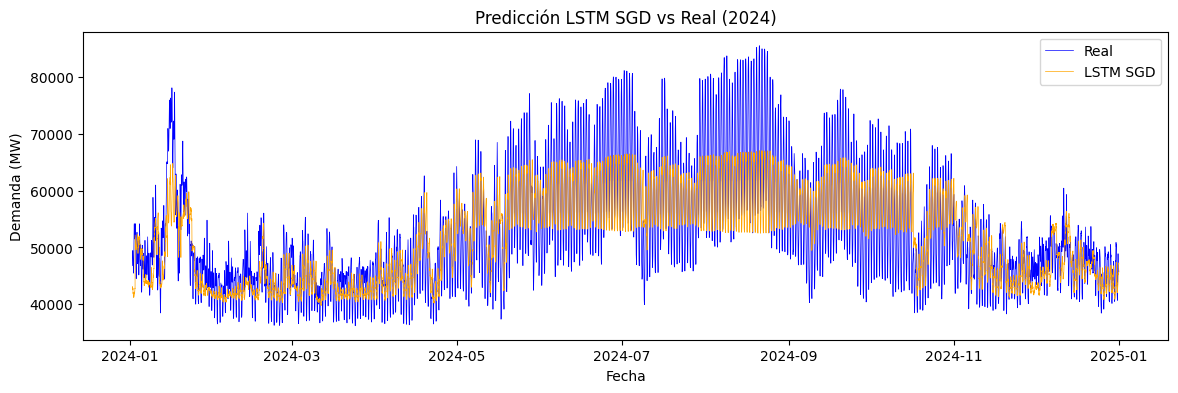

In [32]:
# Evaluar LSTM SGD

r_lstm_sgd = evaluate_lstm(model_sgd, test_loader, name='LSTM SGD', graficar=True)

LSTM SGDM - MAE: 2,425 MW
LSTM SGDM - RMSE: 3,380 MW
LSTM SGDM - MAPE: 4.61 %


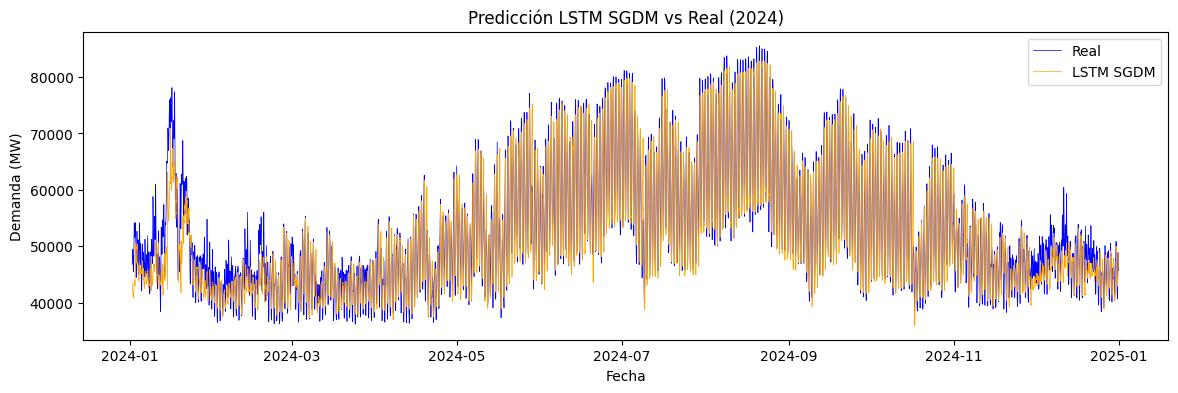

In [33]:
# evaluate LSTM SGD con momentum

r_lstm_sgd = evaluate_lstm(model_sgdm, test_loader, name='LSTM SGDM', graficar=True)

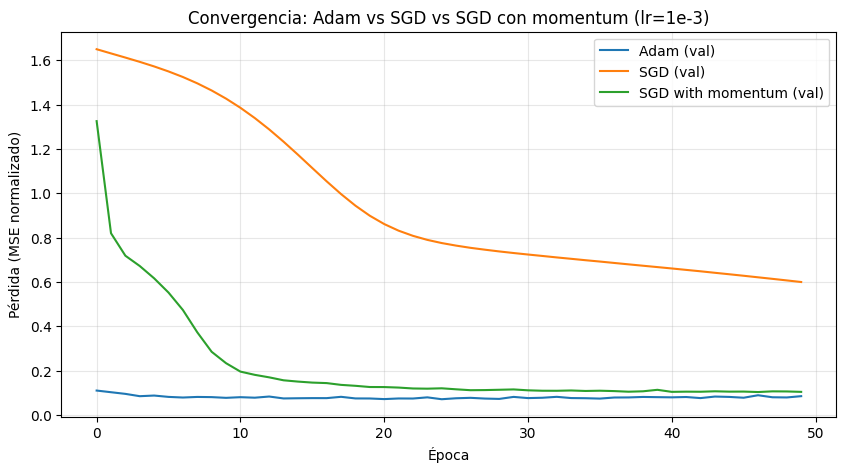

In [34]:
plt.figure(figsize=(10,5))
plt.plot(val_adam, label='Adam (val)')
plt.plot(val_sgd, label='SGD (val)')
plt.plot(val_sgdm, label='SGD with momentum (val)')
plt.xlabel('Época'); plt.ylabel('Pérdida (MSE normalizado)')
plt.title('Convergencia: Adam vs SGD vs SGD con momentum (lr=1e-3)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

___
# Análisis de los experimentos: early stopping, learning rate y optimizadores

### Qué se realizó?

Partiendo del mismo LSTM (`50 neuronas, ventana 24`), se corrieron **6 configuraciones** variando tres cosas de una en una: el **early stopping**, el **learning rate** y el **optimizador**. La idea no era ganarle a SARIMA, sino **entender qué mueve cada perilla** y con qué carácter converge cada versión.

### Resultados consolidados

| Experimento | Config | Mejor val | Época | MAPE test |
|---|---|---:|---:|---:|
| Sin early stopping | Adam, lr=1e-3, 50 ép. | — | 50 | 5.06 % |
| Con early stopping | Adam, lr=1e-3 | 0.0727 | 18 | 4.14 % |
| lr alto | Adam, lr=1e-2 | 0.0744 | 6 | 4.06 % |
| lr bajo | Adam, lr=1e-4 | 0.0788 | 49 | 4.07 % |
| SGD | lr=1e-3 | 0.5690 | 50 | 7.91 % |
| SGD + momentum | lr=1e-3, momentum=0.9 | 0.1013 | 48 | 4.64 % |

*(Recordatorio del piso: Seasonal Naive 24h = 4.51 % · SARIMA = 4.18 %)*

---

### Hallazgo 1 — Overfitting y early stopping

Mirando las curvas de entrenamiento se ve el patrón de manual: el **train loss baja siempre** (el modelo puede seguir *memorizando* los datos que ya vio), pero el **val loss toca fondo alrededor de la época ~18 y después empieza a subir**. Ese punto es exactamente donde el modelo deja de *generalizar* y empieza a *memorizar*.

El impacto es enorme y concreto:

| | Sin early stopping | Con early stopping |
|---|---:|---:|
| Época final | 50 | 18 |
| MAPE test | **5.06 %** | **4.14 %** |

Sin early stopping el LSTM quedó **por encima del piso** (5.06 % > 4.51 % del Seasonal Naive) → *perdía*. Con early stopping quedó **por debajo** (4.14 %) → *gana*. O sea, en este caso el early stopping fue **la diferencia entre perder y ganarle al baseline**: no es un adorno, congela el modelo en su mejor momento de generalización antes de que se eche a perder.

### Hallazgo 2 — Learning rate: la U clásica

Al barrer el learning rate aparece la forma de **U** de siempre ni muy grande ni muy chico:

- **`lr=1e-2` (alto):** converge **rapidísimo** (mejor val en la época **6**), pero a un val un pelín peor (0.0744) y de forma **inestable**, da pasos tan grandes que sobrepasa el mínimo y el val empieza a rebotar hacia arriba (el early stopping lo corta temprano).
- **`lr=1e-4` (bajo):** **estable pero lento**. En la época **49** todavía venía bajando, se quedó sin épocas **antes de terminar de converger** (el peor val, 0.0788).
- **`lr=1e-3` (balance):** el punto medio — alcanza el **mejor val (0.0727)** en una época sana (18).

**El matiz honesto (importante):** en el **MAPE de test los tres están empatados** (4.06 / 4.14 / 4.07 %): esa diferencia es **ruido de semilla**, no señal. No se puede coronar un "ganador" por el MAPE. Lo que de verdad los distingue **no es el resultado final sino el *carácter* de la convergencia**: qué tan rápido, qué tan estable, y si le alcanzan las épocas. Por eso `1e-3` es la elección sensata (converge bien y a tiempo), aunque en la métrica final los tres se toquen.

### Hallazgo 3 — Optimizadores: SGD → +momentum → +adaptación

Aquí se ve una **progresión limpia**, donde cada ingrediente arregla la limitación del anterior:

$$\text{SGD:}\quad \theta \leftarrow \theta - \eta\,g \qquad\qquad \text{+momentum:}\quad v \leftarrow \beta v + g,\;\; \theta \leftarrow \theta - \eta\,v \qquad\qquad \text{Adam:}\quad \theta \leftarrow \theta - \eta\,\tfrac{\hat{m}}{\sqrt{\hat{v}}+\epsilon}$$

| Optimizador | Mejor val | MAPE test | Qué le faltaba al anterior |
|---|---:|---:|---|
| **SGD** | 0.5690 | 7.91 % | — (paso fijo y uniforme, sin memoria) |
| **SGD + momentum** | 0.1013 | 4.64 % | le agrega **inercia** |
| **Adam** (momentum + adaptación) | 0.0727 | 4.14 % | le agrega **lr por-parámetro** |

- **SGD pelón:** apenas aprende (val 0.5690, ni converge en 50 épocas → **7.91 %, peor que el piso**). Con un paso fijo y uniforme se **arrastra** en las zonas planas de la superficie de pérdida y se atora.
- **+ Momentum (β=0.9):** acumula los gradientes pasados como una **"inercia"** que empuja a través de las zonas planas y amortigua el zigzag. Salto brutal: **7.91 % → 4.64 %** (el train loss que con SGD casi no se movía, ahora se desploma).
- **+ Adaptación (Adam):** encima del momentum, le pone un **learning rate distinto a cada parámetro** según la magnitud de su gradiente → maneja parámetros de escalas distintas y **converge más rápido (época 18) y más profundo (mejor val 0.0727)**. Es el único que baja del piso.

La gráfica de convergencia (Adam vs SGD vs SGD+momentum) es la prueba visual: las tres curvas de val separadas muestran justo esa progresión de "cada ingrediente destraba al anterior".

---

### Qué implica

Dos lecciones que se llevan a la siguiente fase:

1. **El early stopping es obligatorio, no opcional** fue lo que puso al LSTM por debajo del piso.
2. **Entre configuraciones casi empatadas, no sobre-interpretes el MAPE final** (es ruido de semilla); la señal está en *cómo* converge cada una. Para afirmar un ganador de verdad entre los Adam habría que promediar varias semillas.

Y el punto de fondo que sigue vigente: todos estos experimentos exprimen la **misma señal** (1 feature, ventana de 24 h). El salto grande no vendrá de otra perilla de entrenamiento, sino de **darle features nuevas al modelo** (temperatura, ciclo semanal de 168 h).


In [35]:
for seed in seeds:
    torch.manual_seed(seed)
    model_adam = SimpleLSTM()
    optimizer = torch.optim.Adam(model_adam.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model_adam, train_adam, val_adam = train_model(model_adam, optimizer, criterion, train_loader, val_loader, num_epochs=50, verbose=False)
    # Evaluar LSTM 
    r_lstm_adam = evaluate_lstm(model_adam, test_loader, name=f'LSTM seed={seed}', graficar=False)
    seed_result.append(r_lstm_adam)


df_seeds = pd.DataFrame(seed_result).set_index('Model')
print(df_seeds.round(2))
for m in ['MAE', 'RMSE', 'MAPE']:
    print(f"\n{m}: media = {df_seeds[m].mean():.3f} | std = {df_seeds[m].std():.3f}")

LSTM seed=0 - MAE: 2,205 MW
LSTM seed=0 - RMSE: 3,090 MW
LSTM seed=0 - MAPE: 4.25 %
LSTM seed=1 - MAE: 2,064 MW
LSTM seed=1 - RMSE: 2,906 MW
LSTM seed=1 - MAPE: 3.92 %
LSTM seed=2 - MAE: 2,135 MW
LSTM seed=2 - RMSE: 2,972 MW
LSTM seed=2 - MAPE: 4.08 %
LSTM seed=3 - MAE: 2,044 MW
LSTM seed=3 - RMSE: 2,898 MW
LSTM seed=3 - MAPE: 3.93 %
LSTM seed=4 - MAE: 2,057 MW
LSTM seed=4 - RMSE: 2,963 MW
LSTM seed=4 - MAPE: 3.94 %
LSTM seed=5 - MAE: 2,155 MW
LSTM seed=5 - RMSE: 3,031 MW
LSTM seed=5 - MAPE: 4.14 %
LSTM seed=6 - MAE: 2,142 MW
LSTM seed=6 - RMSE: 3,053 MW
LSTM seed=6 - MAPE: 4.08 %
LSTM seed=7 - MAE: 2,173 MW
LSTM seed=7 - RMSE: 3,039 MW
LSTM seed=7 - MAPE: 4.16 %
LSTM seed=8 - MAE: 2,068 MW
LSTM seed=8 - RMSE: 2,965 MW
LSTM seed=8 - MAPE: 3.96 %
LSTM seed=9 - MAE: 2,115 MW
LSTM seed=9 - RMSE: 2,946 MW
LSTM seed=9 - MAPE: 4.07 %
                 MAE     RMSE  MAPE
Model                              
LSTM seed=0  2204.97  3089.74  4.25
LSTM seed=1  2064.12  2905.80  3.92
LSTM seed=2  213

In [40]:
from scipy import stats

mapes = [4.25, 3.92, 4.08, 3.93, 3.94, 4.14, 4.08, 4.16, 3.96, 4.07]  # 10 semillas, ventana 24h
t, p = stats.ttest_1samp(mapes, 4.18)   # H0: media del LSTM = 4.18 (SARIMA)
print(f't = {t:.3f} | p = {p:.5f}')

t = -3.571 | p = 0.00601


# Ejecución de LSTM con 10 semillas y promedio de resultados

### Qué se realizó?

Partiendo del mismo LSTM (`50 neuronas, ventana 24, early stopping, Adam, lr=1e-3`), se corrieron **10 semillas distintas** para promediar el resultado y reducir el ruido de inicialización. La idea es **obtener un resultado más robusto** y ver si hay ventaja sobre SARIMA. También se realizó la corrida con **ventana de 168 h** para ver si capturar el ciclo semanal mejora el pronóstico.

## Resultados LSTM con ventana de 168 h

| Modelo | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| LSTM seed=0 | 2,405.33 | 3,260.04 | 4.62 |
| LSTM seed=1 | 2,420.01 | 3,392.67 | 4.67 |
| LSTM seed=2 | 2,239.47 | 3,100.38 | 4.32 |
| LSTM seed=3 | 2,153.50 | 3,037.63 | 4.06 |
| LSTM seed=4 | 2,210.89 | 3,075.00 | 4.25 |
| LSTM seed=5 | 2,238.70 | 3,103.55 | 4.33 |
| LSTM seed=6 | 2,187.14 | 3,071.57 | 4.20 |
| LSTM seed=7 | 2,349.39 | 3,210.93 | 4.52 |
| LSTM seed=8 | 2,432.65 | 3,353.47 | 4.74 |
| LSTM seed=9 | 2,322.08 | 3,210.54 | 4.42 |

### Resumen
| Métrica | Media | Desv. estándar |
|---|---:|---:|
| MAE | 2,295.916 | 102.962 |
| RMSE | 3,181.577 | 124.198 |
| MAPE | 4.415 | 0.220 |


## Resultados LSTM con ventana de 24 h

| Modelo | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| LSTM seed=0 | 2,204.97 | 3,089.74 | 4.25 |
| LSTM seed=1 | 2,064.12 | 2,905.80 | 3.92 |
| LSTM seed=2 | 2,135.42 | 2,972.02 | 4.08 |
| LSTM seed=3 | 2,043.63 | 2,898.47 | 3.93 |
| LSTM seed=4 | 2,056.62 | 2,962.90 | 3.94 |
| LSTM seed=5 | 2,155.02 | 3,031.18 | 4.14 |
| LSTM seed=6 | 2,141.53 | 3,052.62 | 4.08 |
| LSTM seed=7 | 2,172.94 | 3,039.48 | 4.16 |
| LSTM seed=8 | 2,067.94 | 2,965.31 | 3.96 |
| LSTM seed=9 | 2,115.21 | 2,946.31 | 4.07 |

### Resumen
| Métrica | Media | Desv. estándar |
|---|---:|---:|
| MAE | 2,115.739 | 55.252 |
| RMSE | 2,986.382 | 64.054 |
| MAPE | 4.053 | 0.113 |

Con estos resultados se puede visualizar que la ventana de 24 h es mejor que la de 168 h, ya que el MAPE promedio es menor (`4.053 % vs 4.415 %`) y la desviación estándar también es menor (`0.113 vs 0.220`). Esto indica que el modelo con ventana de 24 h es más consistente y preciso.

*(10 de 10 semillas le ganan al piso Seasonal Naive 24h = 4.51 % y 9 de 10 semillas le ganan a SARIMA = 4.18 %)*

| Modelo | MAPE (%) | Naturaleza |
|---|---:|---|
| Piso — Seasonal Naive 24h | 4.51 | determinista |
| SARIMA(2,0,0)(1,1,0)[24] | 4.18 | determinista |
| **LSTM (ventana 24h, 10 semillas)** | **4.05 ± 0.11** | estocástico |

Aquí el margen sobre SARIMA es 0.127 (4.18 - 4.053), y la desviación estándar es 0.113 son casi iguales.

Esto significa que la ventaja del LSTM existe en el promedio, no en cualquier corrida individual. Y una prueba de esto la semilla 0 dio 4.25 % y PERDIÓ contra SARIMA. Si hubiéramos reportado solo esa corrida, nuestra conclusión habría sido la contraria.

Algo a tener en cuenta es que SARIMA es determinista, o sea siempre dara 4.18%, mientras que el LSTM es estocástico, por lo que dependiendo de la semilla puede dar un MAPE mayor o menor. Por eso se promediaron 10 semillas para tener un resultado más robusto y confiable.

### Porque salió así? 

Darle al modelo **más contexto** (una semana entera, que en teoría debería capturar el ciclo semanal) lo dejo peor (`4.053 % vs 4.415 %`) y más inestable (`0.113 vs 0.220`). Porque?

1. En el EDA se vio que la diferencia laboral vs fin de semana es **modesta**  (~48,700 vs ~47,100 MW, ~3%), mientras que el ciclo diario es enorme (razón pico/valle 1.37, ~37%). O sea, la señal nueva que la ventana de 168 h iba a "capturar" es **poca**, por lo tanto no hay mucho premio ahí por así decirlo.
2. Un LSTM no llega a cargar bien 168 pasos. Con `1 capa y 50 neuronas`, el modelo tiene que comprimir toda la semana en el mismo estado oculto de 50 dimensiones ($\mathbb{R}^{50}$). Al estirar la secuencia, diluye las últimas 24h que son las que de verdad predicen, por la fuerte autocorrelación diaria entre 144 horas más de historia que aportan poco. Es algo que juega en contra.
3. Secuencia más larga = optimización más difícil y ruidosa. Por eso el **std** casi se duplico. La ventana de 168h no solo da peor promedio, sino que es menos confiable entre semillas 

En pocas palabras, más contexto solo ayuda **si** hay señal ahí **y** el modelo puede explotarla. En este caso, la señal semanal es débil y el LSTM no puede aprovecharla bien, por eso la ventana de 24h gana.

### Que implica?

el LSTM (ventana 24 h) es el mejor modelo de todos los que probamos, le gana al piso Seasonal Naive (4.51 %), a Holt-Winters (9.21 %) y a SARIMA (4.18 %), de forma robusta (10 semillas) y estadísticamente significativa ($p < 0.01$). Esa es la respuesta a la pregunta de investigación.

___

# Comparación de horizontes de 1h SARIMA vs LSTM

In [51]:
train_window_h1 = TimeSeriesDataset(train_arr, window_size = 24, horizon=1)
val_window_h1 = TimeSeriesDataset(val_arr, window_size = 24, horizon=1)
test_window_h1 = TimeSeriesDataset(test_arr, window_size = 24, horizon=1)

train_loader_h1 = torch.utils.data.DataLoader(train_window_h1, batch_size=32, shuffle=True)
val_loader_h1 = torch.utils.data.DataLoader(val_window_h1, batch_size=32, shuffle=False)
test_loader_h1 = torch.utils.data.DataLoader(test_window_h1, batch_size=32, shuffle=False)

In [52]:
seed_result_h1 = []
for seed in seeds: 
    torch.manual_seed(seed)
    model_adam_h1 = SimpleLSTM(output_size=1)  # Ajustar output_size a 1 para horizonte de 1 hora
    optimizer = torch.optim.Adam(model_adam_h1.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model_adam_h1, train_adam_h1, val_adam_h1 = train_model(model_adam_h1, optimizer, criterion, train_loader_h1, val_loader_h1, num_epochs=50, verbose=False)
    # Evaluar LSTM
    r_lstm_adam_h1 = evaluate_lstm(model_adam_h1, test_loader_h1, name=f'LSTM seed={seed} (h=1)', graficar=False, horizon=1)
    seed_result_h1.append(r_lstm_adam_h1)

df_seeds_h1 = pd.DataFrame(seed_result_h1).set_index('Model')
print(df_seeds_h1.round(2))
for m in ['MAE', 'RMSE', 'MAPE']:
    print(f"\n{m}: media = {df_seeds_h1[m].mean():.3f} | std = {df_seeds_h1[m].std():.3f}")

LSTM seed=0 (h=1) - MAE: 394 MW
LSTM seed=0 (h=1) - RMSE: 538 MW
LSTM seed=0 (h=1) - MAPE: 0.76 %
LSTM seed=1 (h=1) - MAE: 400 MW
LSTM seed=1 (h=1) - RMSE: 540 MW
LSTM seed=1 (h=1) - MAPE: 0.77 %
LSTM seed=2 (h=1) - MAE: 396 MW
LSTM seed=2 (h=1) - RMSE: 537 MW
LSTM seed=2 (h=1) - MAPE: 0.76 %
LSTM seed=3 (h=1) - MAE: 405 MW
LSTM seed=3 (h=1) - RMSE: 554 MW
LSTM seed=3 (h=1) - MAPE: 0.78 %
LSTM seed=4 (h=1) - MAE: 403 MW
LSTM seed=4 (h=1) - RMSE: 546 MW
LSTM seed=4 (h=1) - MAPE: 0.77 %
LSTM seed=5 (h=1) - MAE: 397 MW
LSTM seed=5 (h=1) - RMSE: 542 MW
LSTM seed=5 (h=1) - MAPE: 0.76 %
LSTM seed=6 (h=1) - MAE: 404 MW
LSTM seed=6 (h=1) - RMSE: 548 MW
LSTM seed=6 (h=1) - MAPE: 0.77 %
LSTM seed=7 (h=1) - MAE: 401 MW
LSTM seed=7 (h=1) - RMSE: 543 MW
LSTM seed=7 (h=1) - MAPE: 0.77 %
LSTM seed=8 (h=1) - MAE: 404 MW
LSTM seed=8 (h=1) - RMSE: 546 MW
LSTM seed=8 (h=1) - MAPE: 0.78 %
LSTM seed=9 (h=1) - MAE: 383 MW
LSTM seed=9 (h=1) - RMSE: 525 MW
LSTM seed=9 (h=1) - MAPE: 0.73 %
                    

In [ ]:
pred_sm_1 = walk_forward_sarima(serie, H=1)   # reproduce el experimento de 1h
real_1 = serie.loc[pred_sm_1.index]
r_sm_1 = evaluate(real_1, pred_sm_1, name='SARIMA(2,0,0)(1,1,0)1')

Predicciones descartadas por explotar: 4 de 8776
SARIMA (h=1) filtrado - MAE: 438 MW
SARIMA (h=1) filtrado - RMSE: 602 MW
SARIMA (h=1) filtrado - MAPE: 0.84 %


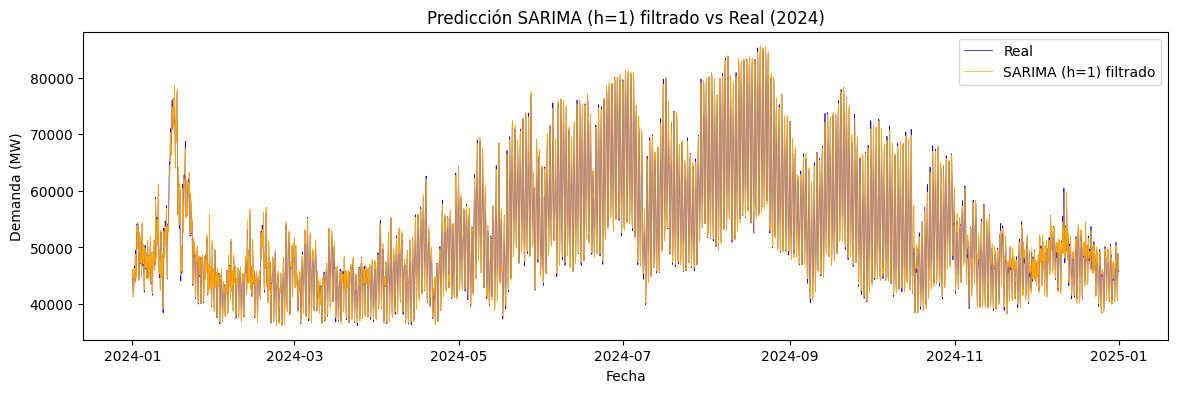

In [ ]:
# Filtrar predicciones que explotan para SARIMA h=1
mask = (pred_sm_1 > 20000) & (pred_sm_1 < 90000)   # descartar predicciones absurdas
pred_limpio = pred_sm_1[mask]
real_limpio = serie.loc[pred_limpio.index]
descartados = (~mask).sum()
print(f"Predicciones descartadas por explotar: {descartados} de {len(pred_sm_1)}")
r_sm_1 = evaluate(real_limpio, pred_limpio, name='SARIMA (h=1) filtrado')

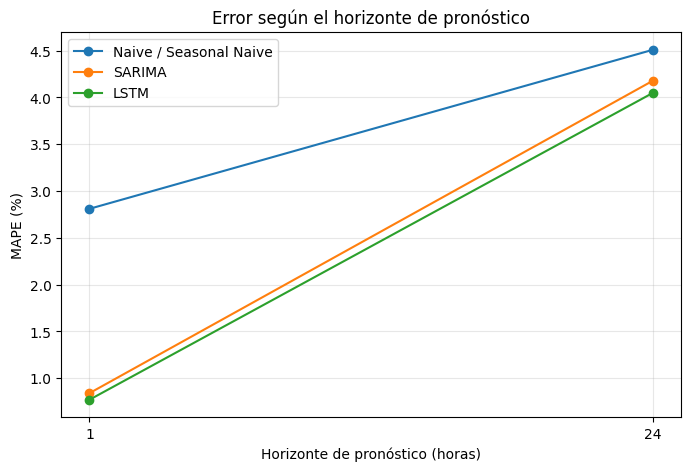

In [ ]:
horizontes = [1, 24]   # eje X

# MAPE de cada modelo en cada horizonte (de tu tabla)
naive   = [2.81, 4.51]   # naive 1h / seasonal naive 24h
sarima  = [0.84, 4.18]
lstm    = [0.77, 4.05]

plt.figure(figsize=(8,5))
plt.plot(horizontes, naive,  marker='o', label='Naive / Seasonal Naive')
plt.plot(horizontes, sarima, marker='o', label='SARIMA')
plt.plot(horizontes, lstm,   marker='o', label='LSTM')

plt.xlabel('Horizonte de pronóstico (horas)')
plt.ylabel('MAPE (%)')
plt.title('Error según el horizonte de pronóstico')
plt.xticks(horizontes)   # que solo marque 1 y 24
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Qué se realizó?

Se evaluaron tres modelos (naive, SARIMA y LSTM) en dos horizontes distintos 1h y 24h para ver como cambia el desempeño según que tan lejos pronosticas. El LSTM y SARIMA se corrieron con la misma configuración que a 24h, solo cambiando el horizonte.

### Cuáles son los resultados?

| Modelo | MAPE @ 1h | MAPE @ 24h |
|---|---:|---:|
| Naive / Seasonal Naive | 2.81 % | 4.51 % |
| SARIMA | 0.84 % | 4.18 % |
| LSTM | 0.77 % ± 0.01 | 4.05 % ± 0.11 |

### Cómo se comparan? 

El **horizonte importa**: el error crece con el horizonte para todos, pero los sofisticados se degradan **~3 veces más rápido en términos relativos** (SARIMA se multiplica ×5.0, el naive solo ×1.6). En términos **absolutos** la diferencia es ~2× (SARIMA sube 3.34 puntos de MAPE; el naive, 1.70). Se degradan más porque tenían mucho más que perder (venían de 0.8 %); el naive ya era malo a 1h, así que "cae" poco.

A 1h el naive es bueno (2.81 %), pero a 24h ya no (4.51 %). SARIMA y LSTM son mejores que el naive en horizonte de 1h y Seasonal Naive en 24h, de hecho los horizontes de 1h y 24h entre los dos modelos casi empatan tanto en horizonte corto (0.84 vs 0.77) como en largo (4.18 vs 4.05). La diferencia real está entre los modelos sofisticados y el naive, no entre sí.

Y el patrón más fuerte: **cuánto le gana SARIMA al naive cambia dramáticamente con el horizonte.**

| | naive → SARIMA | Ventaja relativa |
|---|---|---:|
| **@1h**  | 2.81 → 0.84 | **70 %**  (mejora relativa = (2.81−0.84)/2.81) |
| **@24h** | 4.51 → 4.18 | **7 %**   (mejora relativa = (4.51−4.18)/4.51) |

### Por qué salió así?

**Por qué el error crece con el horizonte**. A 1h el modelo ve el dato real de la hora anterior y puede apoyarse en él. La demanda es tremendamente persistente hora a hora y se vuelve un trabajo fácil como "copiar y corregir tantito", por eso baja a $0.8\%$. A 24 h la tarea es otra, hay que proyectar el día completo a ciegas, sin recibir ningún dato real intermedio.El modelo pronostica la hora 24 apoyándose solamente de la información de hace 24 horas, no de hace una hora.

$$\text{Más lejos = menos información real disponible = más dificil}$$

Haciendo que la incertidumbre se acumula paso a paso.

A 1h los sofisticados **aplastan** al naive; a 24h apenas lo **arañan**. Ese derrumbe del 70 % al 7 % es lo que explica el mecanismo siguiente:


$$\text{SARIMA} = \text{Seasonal Naive} + \text{corrección autorregresiva}$$

Esta corrección AR decae con el horizonte. A 1h esta en su punto más fuerte (se apoya en $y_{t-1}$, $y_{t-2}$, que conoce) -> por eso aplasta al naive ($70\%$). A 24 h la corrección ya se desvaneció, y SARIMA queda reducido a casi al Seasonal Naive por eso apenas le gana ($7\%$). Y el LSTM, aunque no es lineal, sufre lo mismo: sin dato reciente, ambos terminan apoyados en el mismo ciclo diario que el naive ya explota.

**Por qué el $0.8\%$ NO significa "predecimos el futuro casi perfecto"**. Esto es porque en una operación real, para predecir la hora $t$ necesitas $y_{t-1}$ que solo existe cuando la hora $t-1$ ya pasó. O sea, el pronóstico a 1h solo sirve si estás dispuesto a esperar hasta 60 minutos antes.

ERCOT necesita programar generación con un día de anticipación, y ahí no hay valores intermedios. Entonces el número operativamente relevante es el $\sim 4.05\%$, no el 0.8%. El 0.8 % es real, pero responde a una pregunta mucho más fácil. Es exactamente el mismo razonamiento que se aplico al Naive(t-1) en la sección de baselines: parecía el mejor (2.81 %) pero era engañoso, porque no es un pronóstico real para el horizonte que importa.

### Que implica?

La respuesta a "Bajo que condiciones gana el LSTM?" gana en ambos horizontes, con un margen pequeño pero consistente 0.77 vs 0.84 a 1h (8.3 % relativo) y 4.05 vs 4.18 a 24h (3.1 % relativo). Pero igual SARIMA es un buen modelo, no hay un ganador que aplaste al otro por así decirlo en precisión pura. Con un matiz que si se distingue: medido contra el ruido de semilla, la victoria del LSTM a 1h es decisiva ($5.4 \sigma$), mientras que a 24h es marginal ($1.1 \sigma$). Su superioridad esta mejor establecida en horizonte corto.
Algo también a tener en cuenta es que el MAPE no lo cuenta todo. Al correr los experimentos aparecieron dos diferencias que ninguna métrica de error captura:

Una de ellas es que SARIMA resulto ser numéricamente frágil. llego a producir predicciones explotadas que hubo que filtrar a mano ($ < 20,000$ y $>90,000$). Fueron pocas (4 de 8,776 el 0.05 %) pero el punto no es la cantidad es que el modelo requirió de intervención manual para dar una métrica usable.

Otro problema es el costo computacional. El walk-forward de SARIMA a 1h necesita $\sim 8,784$ reajustes (uno por cada origen de pronóstico) dando casi 6 horas de ejecución. El LSTM, en cambio, entrena una sola vez y luego predice todo el test en una pasada. La razón es que el costo de SARIMA escala con el número de origenes de pronóstico, mientras el LSTM amortiza  el aprendizaje en un entrenamiento único y su inferencia no es casi nada.

Y hay un punto más fuerte que el costo. Esa asimetría significa que **SARIMA se reajusta cada hora con datos frescos**, mientras el **LSTM se entrenó UNA sola vez con datos viejos (2020–2022)** y nunca volvió a ver nada de 2024. O sea: el LSTM gana **a pesar de trabajar con menos información reciente** que SARIMA. Eso no debilita su ventaja sino pues la **refuerza**.
___

# Conclusión final 

| Modelo | MAPE @ 1h | MAPE @ 24h | MAE @ 24h | RMSE @ 24h |
|---|---:|---:|---:|---:|
| Naive (t-1)¹ | 2.81 % | — | — | — |
| Seasonal Naive 24h *(piso)* | — | 4.51 % | 2,359 | 3,405 |
| Seasonal Naive 168h | — | 8.33 % | 4,476 | 6,265 |
| Holt-Winters WF | — | 9.21 % | 4,676 | 6,670 |
| SARIMA(2,0,0)(1,1,0)[24] | 0.84 % | 4.18 % | 2,164 | 3,144 |
| **LSTM (10 semillas)** | **0.77 % ± 0.01** | **4.05 % ± 0.11** | **2,116 ± 55** | **2,986 ± 64** |

<small>El baseline apropiado cambia con el horizonte: a 1h es Naive(t-1); a 24h es Seasonal Naive 24h. No es el mismo modelo en ambas columnas, por eso los guiones.</small>

El LSTM es el mejor modelo en ambos horizontes, le gana a SARIMA y a todos los baselines, de forma robusta (media de 10 semillas) y estadísticamente significativa (t-test vs SARIMA, $p < 0.01$). Pero el margen sobre SARIMA en precisión pura es pequeño ($\sim 3\%$ relativo a 24h, $\sim 8\%$ relativo a 1h), así que no hay un ganador excelente por asi decirlo. Su ventaja decisiva no está en el _MAPE_ sino en lo operativo: el LSTM es estable entre semillas, entrena una sola vez y no necesita parches manuales, mientras que SARIMA resulto frágil (predicciones que murieron y tuvieron que ser filtradas a mano) y caro (6h de cómputo en el walk-forward a 1h). 

Para este problema, el LSTM gana por un margen modesto pero consistente en precisión, y más claramanete en robustez y costo computacional.

### Limitaciones y trabajo futuro 

| Limitación | Trabajo futuro |
|---|---|
| **Modelos univariados:** todos usan solo demanda pasada, pero el EDA mostró que el clima domina la demanda (picos de verano, heterocedasticidad). | Añadir temperatura + features de calendario (día de semana, festivos) como regresores exógenos: SARIMAX / LSTM multivariado. |
| **Orden de SARIMA elegido a mano** (ACF/PACF, Box-Jenkins), una sola configuración. | Usar `auto_arima` (pmdarima) para búsqueda sistemática del orden y una comparación más justa. |
| **Arquitectura LSTM mínima:** 1 capa, 50 unidades, unidireccional, sin tuning. | Probar Bi-LSTM, capas apiladas y atención, con búsqueda de hiperparámetros (`hidden_size`, `num_layers`, ventana). |
| **Rigor estadístico limitado:** t-test pareado contra un valor fijo. | Aplicar test de Friedman + post-hoc Nemenyi para un ranking correcto entre todos los modelos, no solo LSTM vs SARIMA. |
| **Se reporta la media de 10 semillas, pero en producción se usaría una sola.** | Usar ensemble de semillas: promediar las predicciones de los 10 modelos para un predictor único y más estable. |
